<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Data Science and Business Analytics</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [2]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.2.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [3]:
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import GridSearchCV
# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# **Loading the dataset**

In [4]:
# mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
ev_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/EasyVisa.csv')

In [6]:
#creating a copy of the data
easy_visa_df = ev_df.copy()

# **Overview of the Dataset**

* Observations

* Sanity checks

In [7]:
#Print the first few rows of dataset
print(easy_visa_df.head())

  case_id continent education_of_employee has_job_experience  \
0  EZYV01      Asia           High School                  N   
1  EZYV02      Asia              Master's                  Y   
2  EZYV03      Asia            Bachelor's                  N   
3  EZYV04      Asia            Bachelor's                  N   
4  EZYV05    Africa              Master's                  Y   

  requires_job_training  no_of_employees  yr_of_estab region_of_employment  \
0                     N            14513         2007                 West   
1                     N             2412         2002            Northeast   
2                     Y            44444         2008                 West   
3                     N               98         1897                 West   
4                     N             1082         2005                South   

   prevailing_wage unit_of_wage full_time_position case_status  
0         592.2029         Hour                  Y      Denied  
1       83425.65

In [8]:
print(easy_visa_df.shape)
#Print the number of rows and columns in the dataset
print("Number of rows:", easy_visa_df.shape[0])
print("Number of columns:", easy_visa_df.shape[1])

(25480, 12)
Number of rows: 25480
Number of columns: 12


In [9]:
#print the datatypes in the dataset
print(easy_visa_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB
None


In [10]:
#Check for the missing values in Dataset
easy_visa_df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


In [11]:
#Check for the duplicated values in Dataset
print(easy_visa_df.duplicated().sum())

0


In [12]:
#Check the statistical summary of data
easy_visa_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


***Observations:***

 - The dataset has 25480 rows and 12 columns
 - There are no missing values in the dataset
 - There are no duplicate values in the dataset
 - no_of_employees, yr_of_estab, and prevailing_wage are numeric features while rest are objects
 - The no of employees has a mean of 5,667 and median of 2,109. This indicates that the distribution is skewed
 - There are negative values in the no of employees which could be an error
 - yr of estab ranges from 1800 to 2016
 - prevailing wage ranges from 2 to 319,210 and distribution is skewed
 - The most popular continent is Asia
 - The most popular educational level is Bachelor


# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**

What is the distribution of visa case statuses (certified vs. denied)?


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

***Investigate and Fix the negative values in number of employees(no_of_employees) column***

In [13]:
#Get the negative values
negative_values = easy_visa_df[easy_visa_df['no_of_employees'] < 0]
#print the count of negative values
print('There are',len(negative_values),'rows with negative values in no_of_employees column')


There are 33 rows with negative values in no_of_employees column


***Observation:***

 - Employee count cannot be negative. 33 entries were affected.
 - To preserve the integrity of the dataset, we will convert the negative values to their absolute values.

In [14]:
#convert negative values to their absolute values
easy_visa_df['no_of_employees'] = easy_visa_df['no_of_employees'].abs()

***check the count of each unique category in each of the categorical variables***

In [15]:
# Select object-type columns
categorical_columns = easy_visa_df.select_dtypes(include='object').columns
print("Categorical Columns:")
print(categorical_columns)

# Show value counts for each categorical column
for col in categorical_columns:
    print(f"\nValue counts for '{col}':")
    print(easy_visa_df[col].value_counts(True))
    print('---'*20)

Categorical Columns:
Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

Value counts for 'case_id':
case_id
EZYV25480    0.000039
EZYV01       0.000039
EZYV02       0.000039
EZYV03       0.000039
EZYV04       0.000039
               ...   
EZYV13       0.000039
EZYV12       0.000039
EZYV11       0.000039
EZYV10       0.000039
EZYV09       0.000039
Name: proportion, Length: 25480, dtype: float64
------------------------------------------------------------

Value counts for 'continent':
continent
Asia             0.661735
Europe           0.146468
North America    0.129199
South America    0.033438
Africa           0.021625
Oceania          0.007535
Name: proportion, dtype: float64
------------------------------------------------------------

Value counts for 'education_of_employee':
education_of_employee
Bachelor's     0.4

***Observation:***
  
   - Case id can be dropped
   - 66% of the applicants are from Asia
   - 40% of the applicants have a bachelor's degree
   - 58% of the applicants have job experience
   - 88% of the applicants do not require job training
   - 28% of the applicants have their worksite in the Northeast region of the US
   - 90% of the applicants have a yearly unit of wage
   - 89% of the visa applications are having a full-time job positions
   - 66% of the case status are certified

In [16]:
#dropping the case_id column
easy_visa_df.drop('case_id',axis=1,inplace=True)

## Univariate Analysis

### Functions required for EDA

In [17]:
# function to create labeled barplots


def labeled_barplot(data, feature,order,perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette='Paired',
        order=data[feature].value_counts().index[:n].sort_values(),


    )

    for p in ax.patches:
        if perc == True:
            label = '{:.1f}%'.format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha='center',
            va='center',
            size=12,
            xytext=(0, 5),
            textcoords='offset points',
        )  # annotate the percentage

    plt.show()  # show the plot

In [18]:
# function to create histplot abd boxplot
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={'height_ratios': (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color='violet'
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color='green', linestyle='--'
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color='black', linestyle='-'
    )  # Add median to the histogram

In [19]:
# function to create histplot and boxplot for numerical columns
def plot_numerical(df, column_name):
    """
    Plot a histogram and boxplot for a numerical column in the DataFrame.

    Parameters:
        df (pd.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the numerical column to plot.
    """
    # Check if the column exists in the DataFrame
    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' does not exist in the DataFrame")

    # Suppress warnings for cleaner output
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')

        # Create subplots (1 row, 2 columns)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 5))  # Correct layout

        # Plot histogram
        sns.histplot(df[column_name], bins=30, kde=False, color='skyblue', ax=ax1)
        ax1.set_title(f'Histogram of {column_name}')
        ax1.set_xlabel(column_name)
        ax1.set_ylabel('Frequency')

        # Plot boxplot
        sns.boxplot(y=df[column_name], color='skyblue', ax=ax2)
        ax2.set_title(f'Boxplot of {column_name}')
        ax2.set_xlabel('')
        ax2.set_ylabel(column_name)

        # Adjust layout
        plt.tight_layout()

    return fig.show()

In [20]:
# list of numerical columns
numerical_cols = [col for col in easy_visa_df.columns if easy_visa_df[col].dtype != 'O']
numerical_cols

['no_of_employees', 'yr_of_estab', 'prevailing_wage']

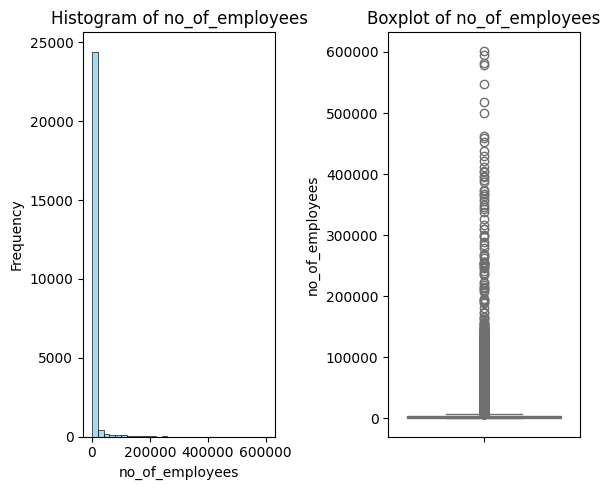

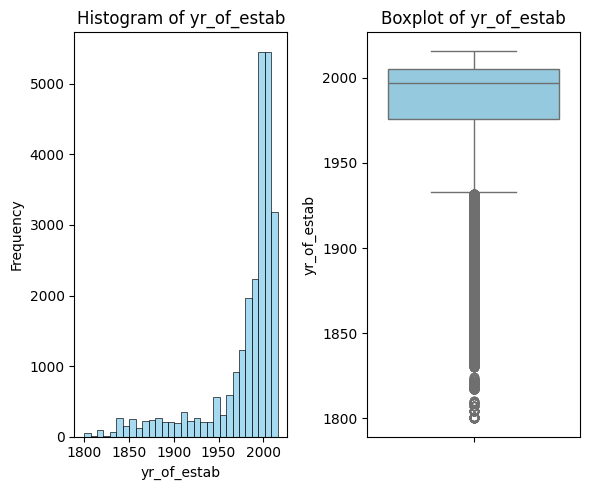

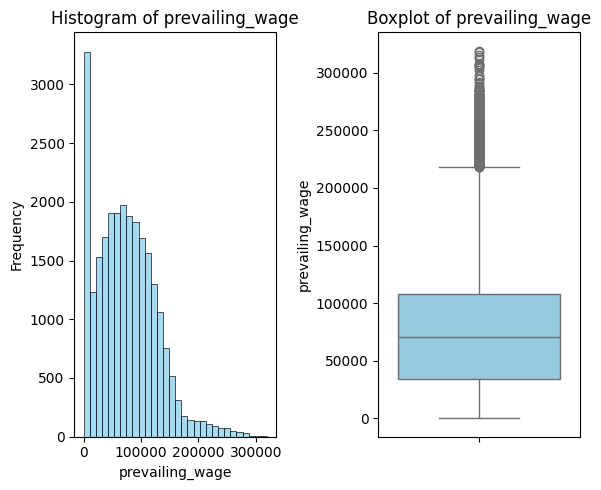

In [21]:
for num_col in numerical_cols:
    plot_numerical(easy_visa_df, num_col)

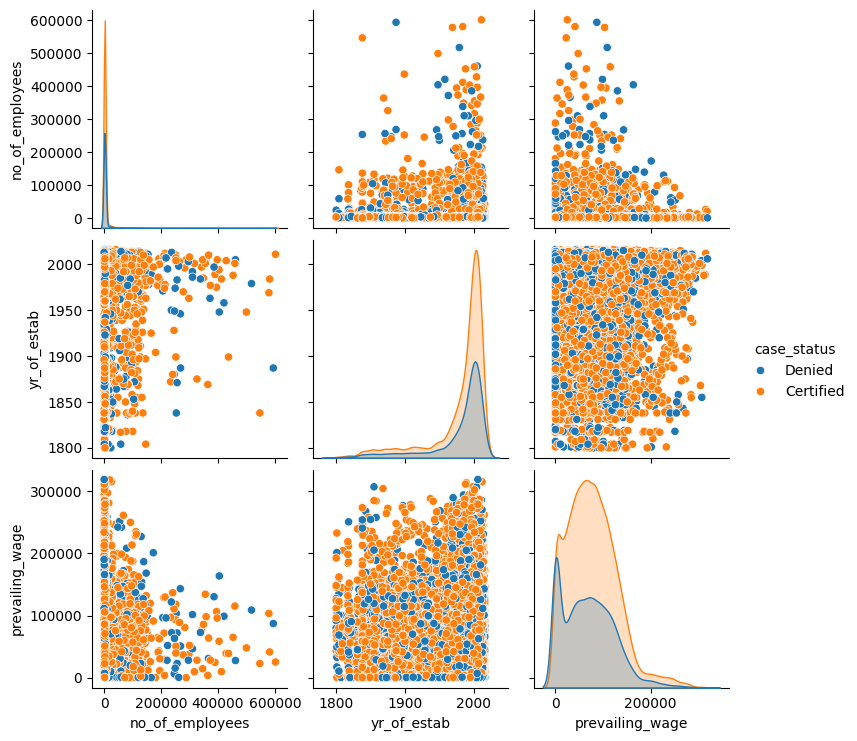

In [22]:
#pairplot for the data
sns.pairplot(easy_visa_df,hue = 'case_status')
plt.show()

### Observations on number of employees

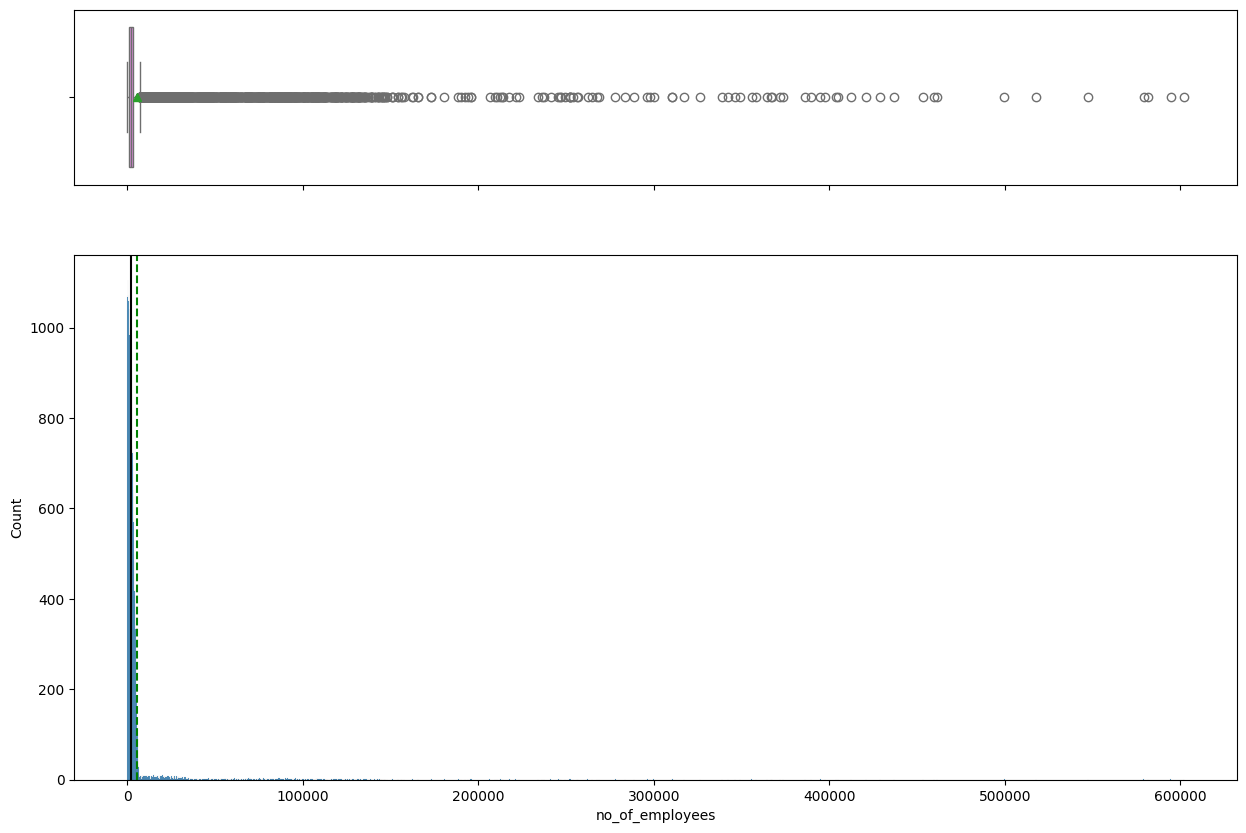

In [23]:
histogram_boxplot(easy_visa_df, 'no_of_employees')

 - We see the distribution of the number of employees is extremly skewed to the right, it implies that the dataset has small companies, medium companies, and large international companies.

### Observations on Prevailing wage

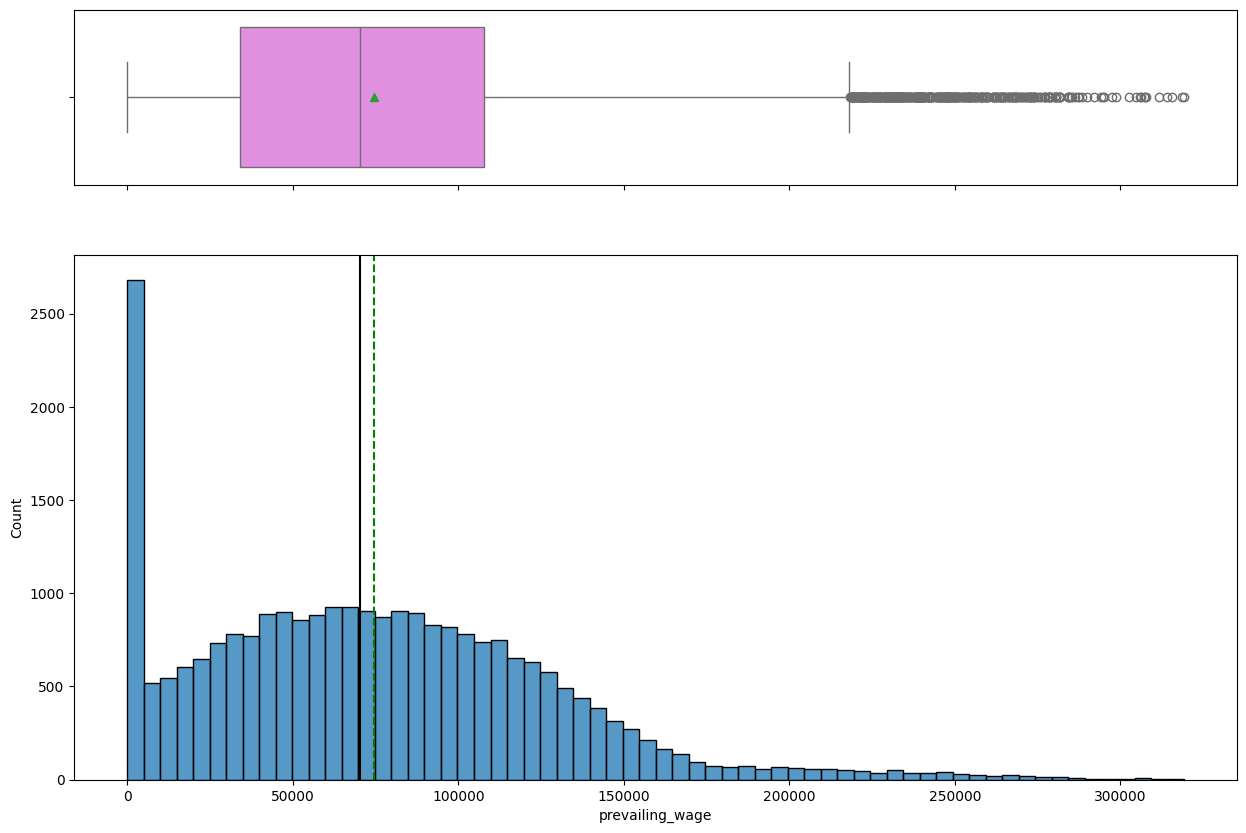

In [24]:
histogram_boxplot(easy_visa_df, 'prevailing_wage')

In [25]:
easy_visa_df.loc[easy_visa_df['prevailing_wage'] < 100, 'unit_of_wage'].value_counts()

,count
unit_of_wage,
Hour,176


 - We see the distribution of the prevailing wage is skewed to the right,
there’s a big gap between the highest and lowest reported values.
 - Some applicants earn over $150,000, while others show near-zero wages, which might be a result of different reporting formats like hourly rates versus annual salaries.

### Observations on Continent

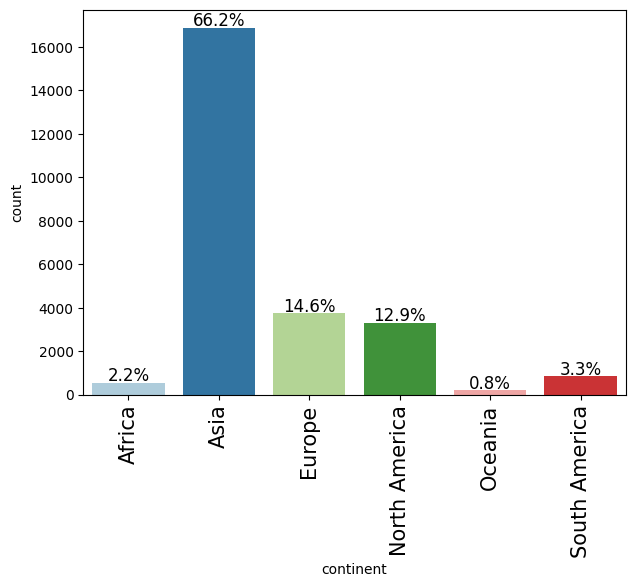

In [26]:
labeled_barplot(easy_visa_df, 'continent', order = None, perc = True)

 - Around 66% are coming from Asia, 15% are coming from Europe, and 13% are coming from North Amercia.


### Observations on education of employee

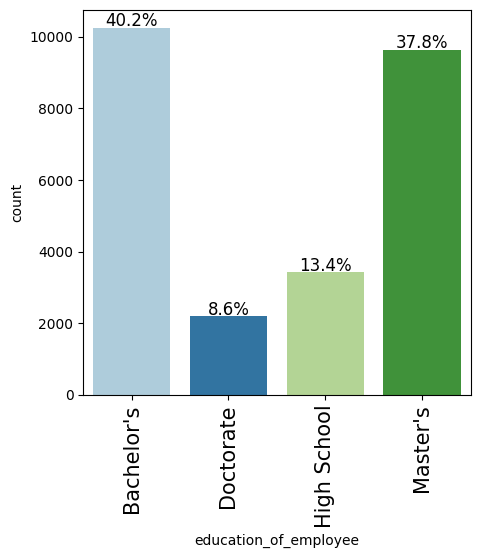

In [27]:
labeled_barplot(easy_visa_df, 'education_of_employee',order = None, perc = True)

 - 40.2% of the applicants have a bachelor's degree, followed by 37.8% having a master's degree and 8.6% of the applicants have a doctorate degree.

### Observations on job experience

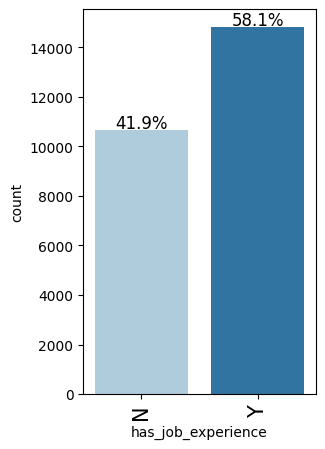

In [28]:
labeled_barplot(easy_visa_df, 'has_job_experience',order = None,perc = True)

 - 58.1% of the applicants have job experience.

### Observations on job training

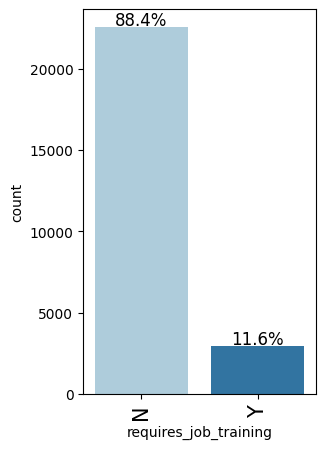

In [29]:
labeled_barplot(easy_visa_df, 'requires_job_training',order = None, perc = True)

 - 11.6% of the applicants require job training.

### Observations on region of employment

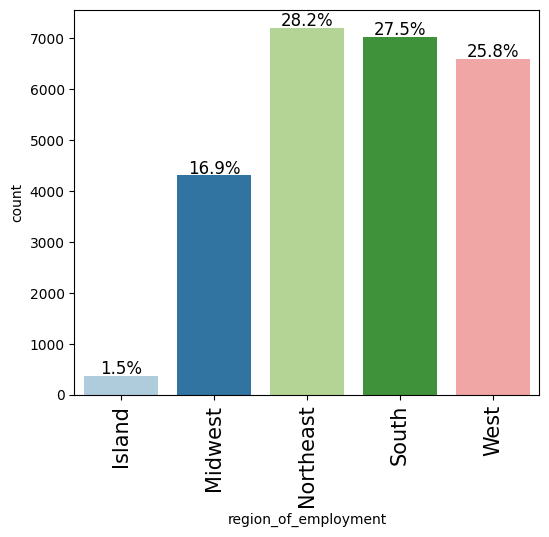

In [30]:
labeled_barplot(easy_visa_df, 'region_of_employment',order = None,perc = True)

 - Northeast, South, and West are equally distributed.
 - The Island regions have only 1.5% of the applicants.

### Observations on unit of wage

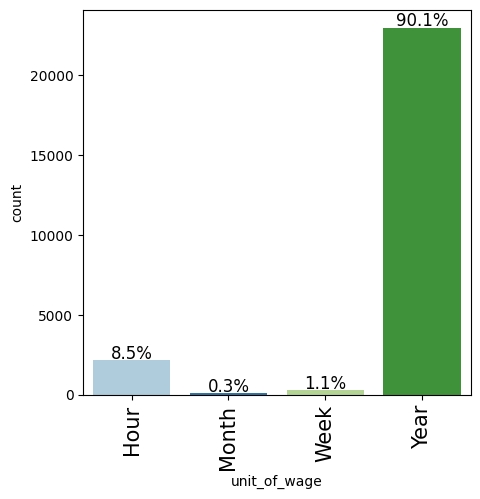

In [31]:
labeled_barplot(easy_visa_df, 'unit_of_wage',order = None,perc = True)



*   Yearly compensation is the most popular mode of payment followed by Hourly,Weekly and Monthly.


### Observations on Full time position

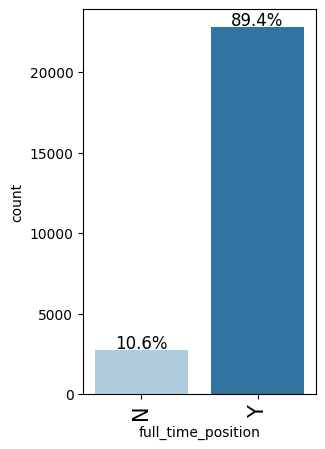

In [32]:
labeled_barplot(easy_visa_df, 'full_time_position',order = None,perc = True)

In [33]:
easy_visa_df['full_time_position'].value_counts()

,count
full_time_position,
Y,22773
N,2707




*   The dataset has 22773 entries for Full time positions, 2707 entries for parttime positions.



### Observations on Case status

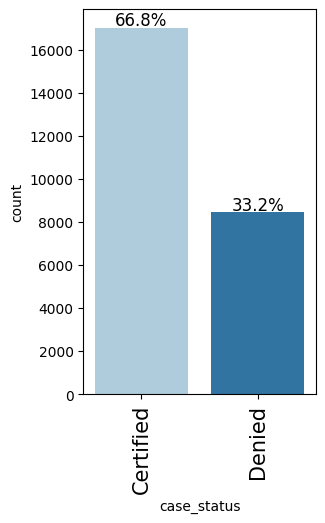

In [34]:
labeled_barplot(easy_visa_df, 'case_status',order = None,perc = True)

In [35]:
easy_visa_df['case_status'].value_counts()

,count
case_status,
Certified,17018
Denied,8462




*   We see that Visa was approved for 17018 applicants and denied for 8462 applicants.



## Bivariate Analysis

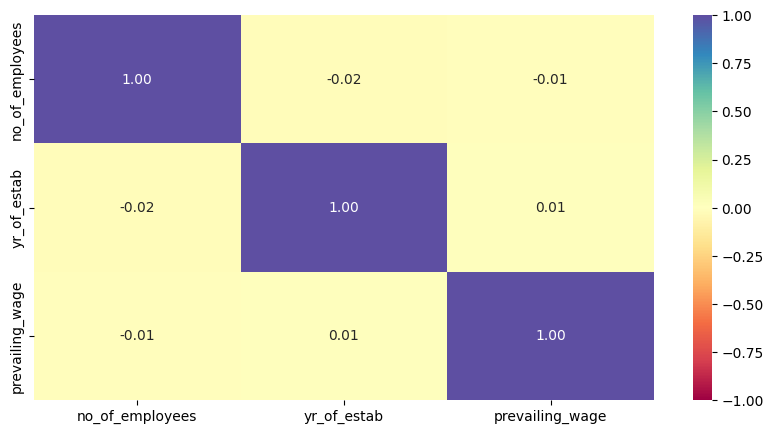

In [36]:
# seperate the numerical values
cols_list = easy_visa_df.select_dtypes(include=np.number).columns.tolist()

# create the correlation matrix
plt.figure(figsize=(10, 5))
sns.heatmap(easy_visa_df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt='.2f', cmap='Spectral')
plt.show()

 - we see no correlation between the numerical variables.

In [37]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title('Distribution of case status=' + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color='teal',
        stat='density',
    )

    axs[0, 1].set_title('Distribution of case status=' + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color='orange',
        stat='density',
    )

    axs[1, 0].set_title('Boxplot w.r.t case status')
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette='gist_rainbow')

    axs[1, 1].set_title('Boxplot (without outliers) w.r.t case status')
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette='gist_rainbow',
    )

    plt.tight_layout()
    plt.show()

In [38]:
# function to create stacked barplot
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize='index').sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind='bar', stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc='lower left', frameon=False,
    )
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.show()

#####1. What is the distribution of visa case statuses (certified vs. denied)?#####

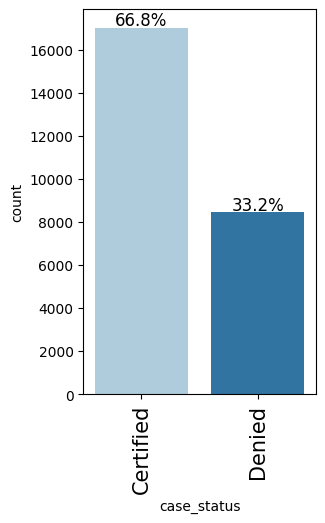

In [39]:
labeled_barplot(easy_visa_df, 'case_status',order = None,perc = True)

***Answer:***

***66.8% of the visas were certified.***

#####2. How does the education level of employees impact visa approval rates?

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


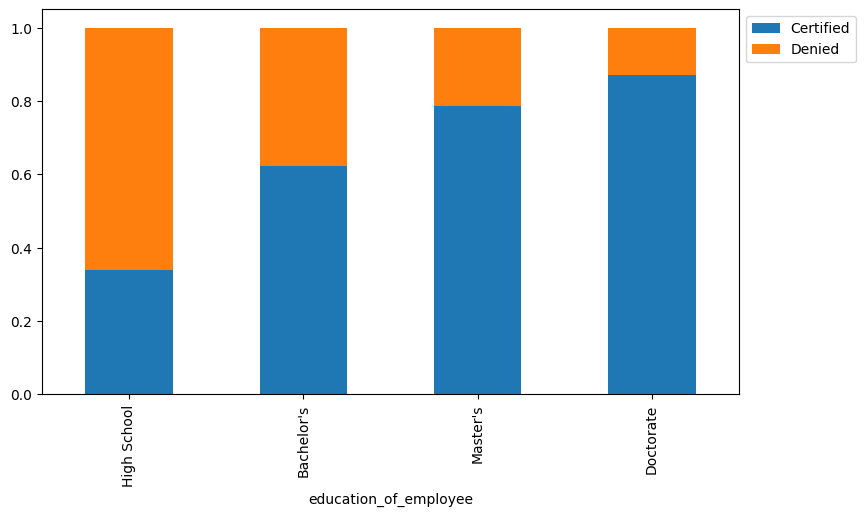

In [40]:
stacked_barplot(easy_visa_df, "education_of_employee", "case_status")

***Answer:***

***The higher the education, the more chance to get certified***

#####3. Is there a significant difference in visa approval rates between employees with and without prior job experience?


case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


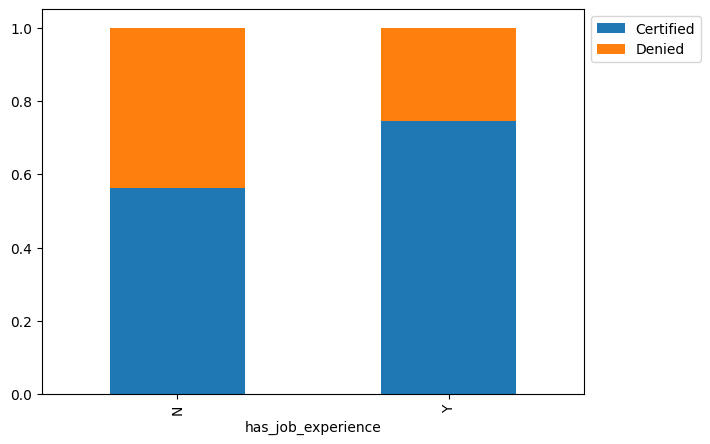

In [41]:
stacked_barplot(easy_visa_df, "has_job_experience", "case_status")

***Answer:***

 - Applicants with job experience have a higher proportion of certified visas.


#####4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?


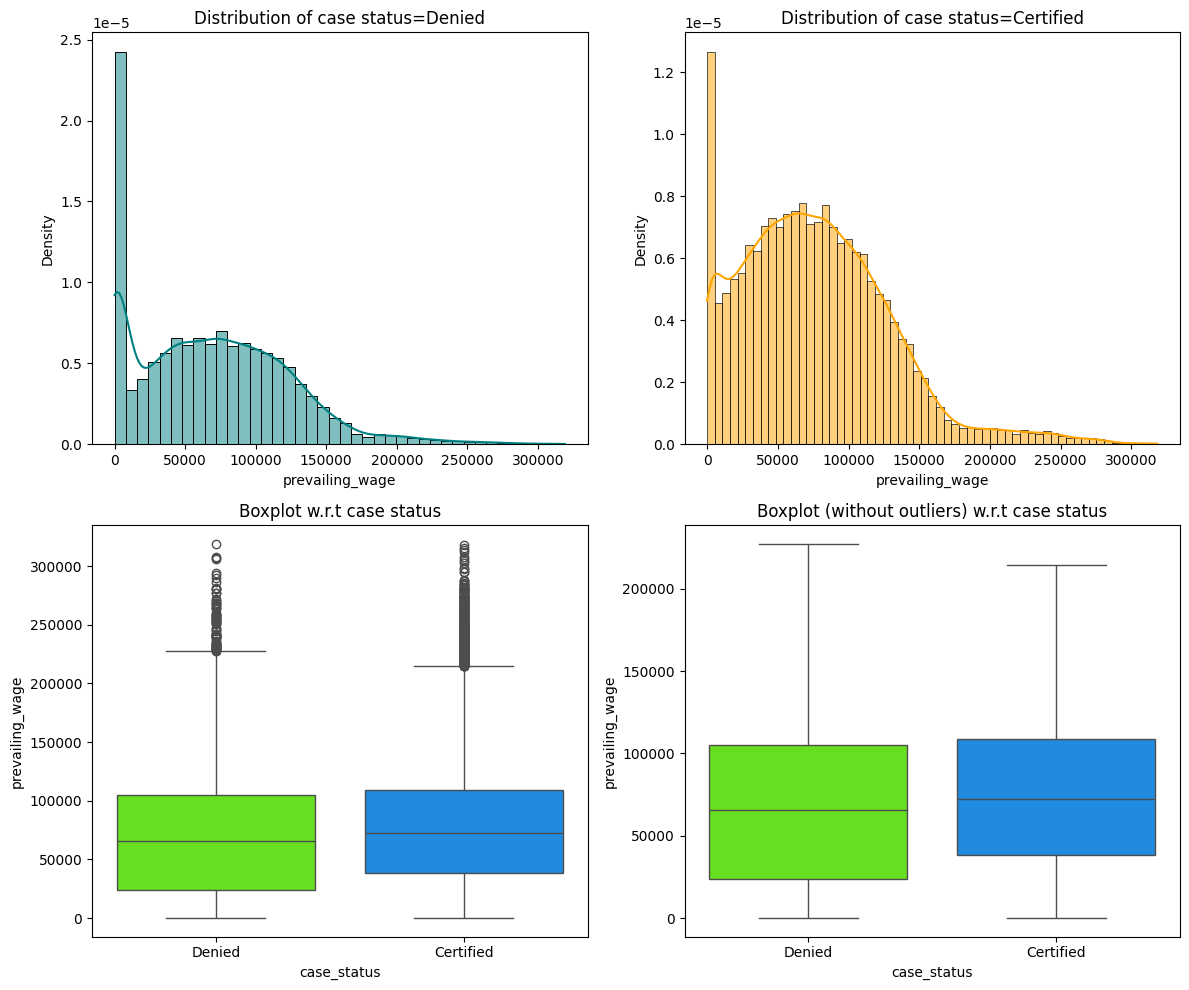

In [42]:
distribution_plot_wrt_target(easy_visa_df, "prevailing_wage", "case_status")

In [43]:
easy_visa_df.groupby('unit_of_wage')['prevailing_wage'].mean()

,prevailing_wage
unit_of_wage,
Hour,414.570513
Month,87592.864045
Week,85606.820515
Year,81228.077133


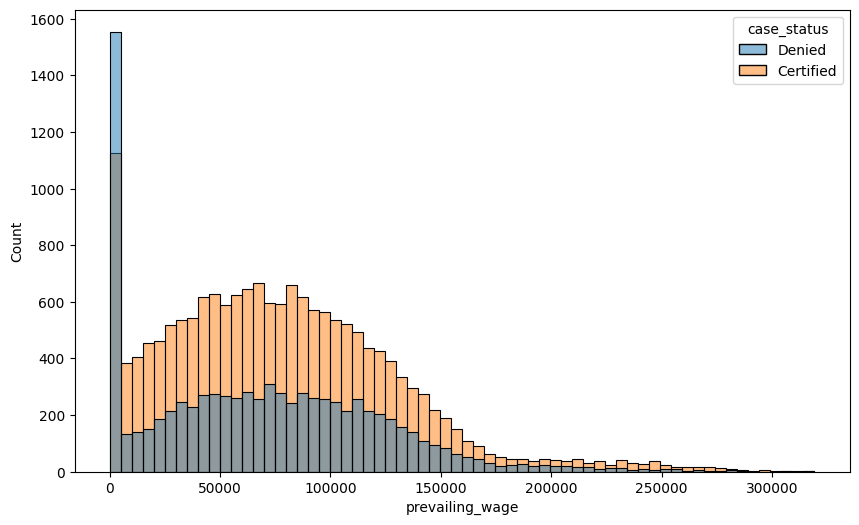

In [44]:
#visualize the distribution of prevailing_wage
plt.figure(figsize=(10,6))
sns.histplot(data=easy_visa_df, x='prevailing_wage', hue='case_status')
plt.show()

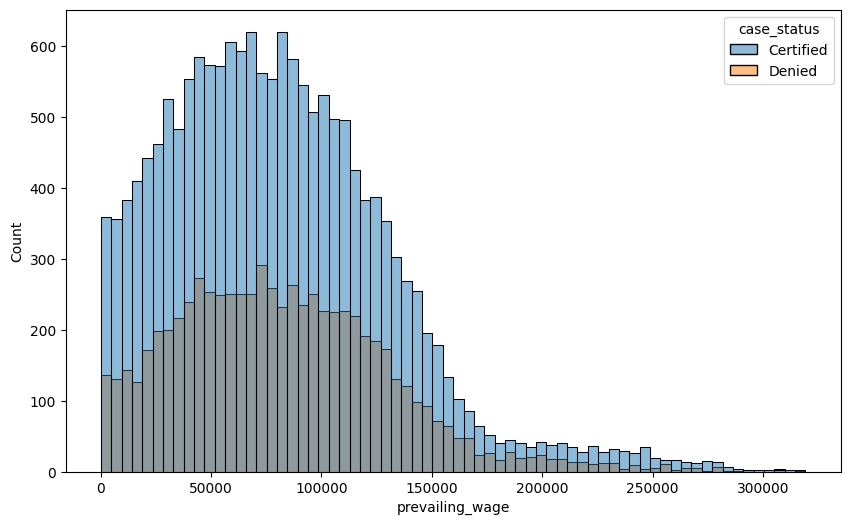

In [45]:
#creating a new dataframe of only those applicants applying for jobs with annual salaries (i.e., not 'Hour')
ev_annual = easy_visa_df[easy_visa_df.unit_of_wage != "Hour"]
#visualize the distribution of annual salaries
plt.figure(figsize=(10,6))
sns.histplot(data=ev_annual, x='prevailing_wage', hue='case_status')
plt.show()

***Answer:***
 - Approved cases trend toward higher median pay compared to denials.

#####5. Do certain regions in the US have higher visa approval rates compared to others?


case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


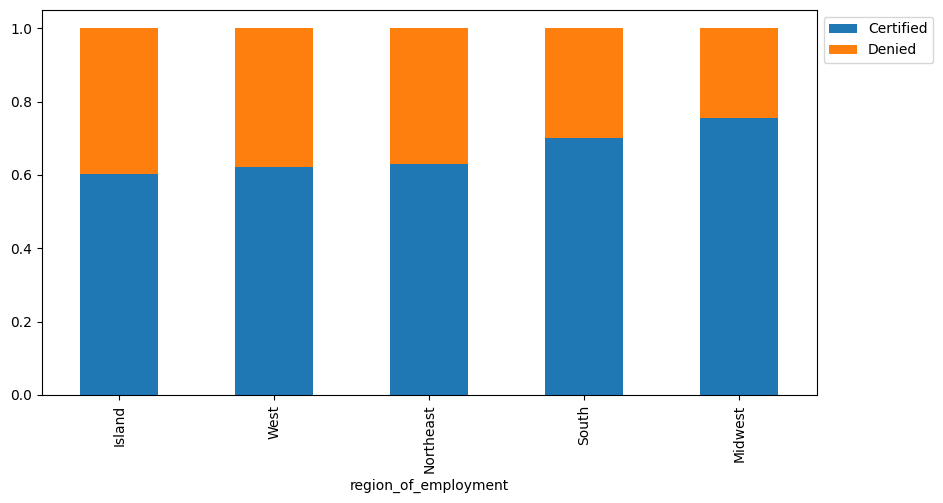

In [46]:
stacked_barplot(easy_visa_df, "region_of_employment", "case_status")

***Answer:***

 - The Midwest region shows the highest likelihood of positive case outcomes, whereas the Island region shows the lowest.

#####6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?


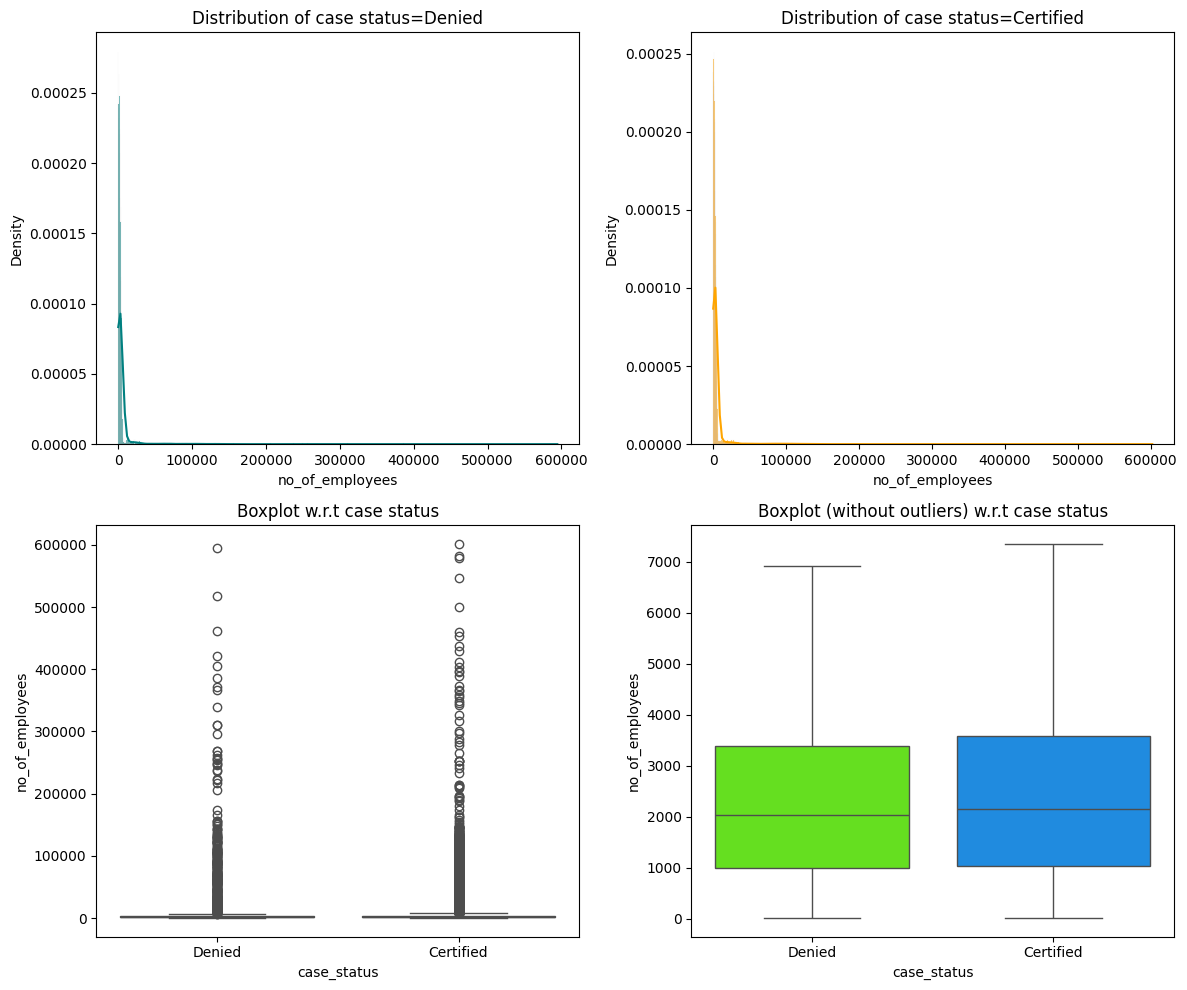

In [47]:
distribution_plot_wrt_target(easy_visa_df, "no_of_employees", "case_status")

In [48]:
easy_visa_df.groupby("case_status")["no_of_employees"].mean()


,no_of_employees
case_status,
Certified,5807.055882
Denied,5385.601040


***Answer:***

 - We see that for certified cases peaks at greater company sizes, and the corresponding boxplot sits noticeably higher than the one for denied applications.
 - The mean employee counts of roughly 5,807 for certified and about 5,385 for denied. This suggests that larger companies indeed enjoy higher approval rates

#####7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

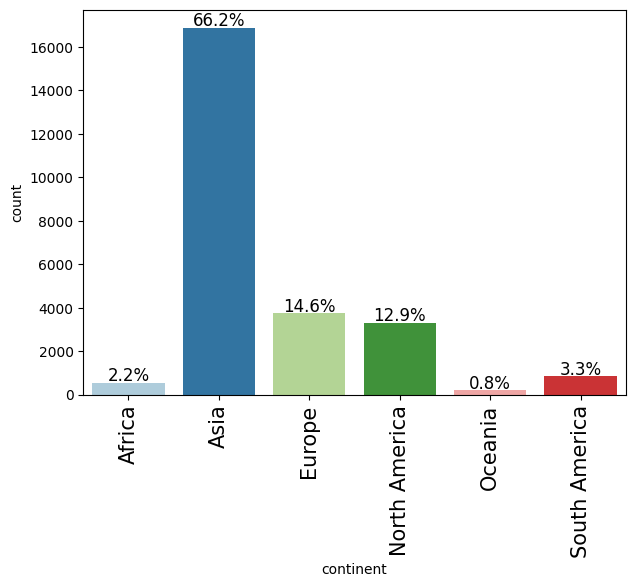

In [49]:
labeled_barplot(easy_visa_df, "continent", order = None,perc = True)

In [50]:
easy_visa_df.groupby("case_status")["continent"].value_counts()

case_status  continent    
Certified    Asia             11012
             Europe            2957
             North America     2037
             South America      493
             Africa             397
             Oceania            122
Denied       Asia              5849
             North America     1255
             Europe             775
             South America      359
             Africa             154
             Oceania             70
Name: count, dtype: int64

***Answer:***

 - Europe has the highest chance of getting certified, while South America has the lowest chance

#### Checking if the prevailing wage is similar across all the regions of the US

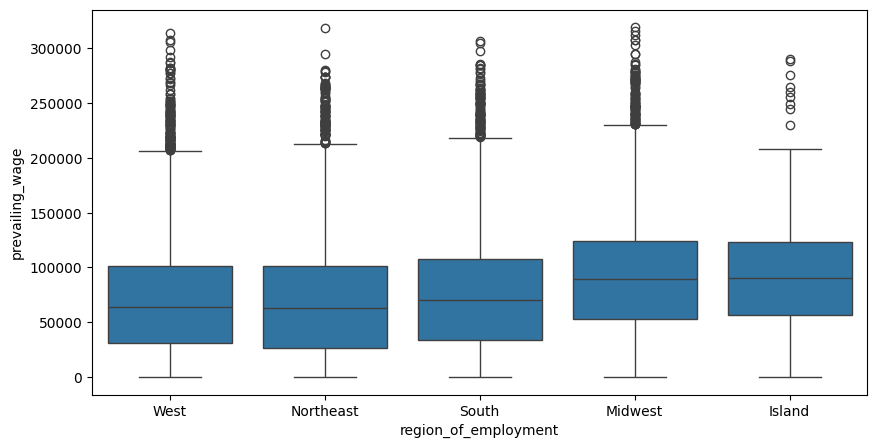

In [51]:
plt.figure(figsize=(10, 5))
sns.boxplot(easy_visa_df, x="region_of_employment", y="prevailing_wage")
plt.show()

 - Prevailing wage is higher in Midwest and Island.

#### Observations on yr_of_estab and case_status

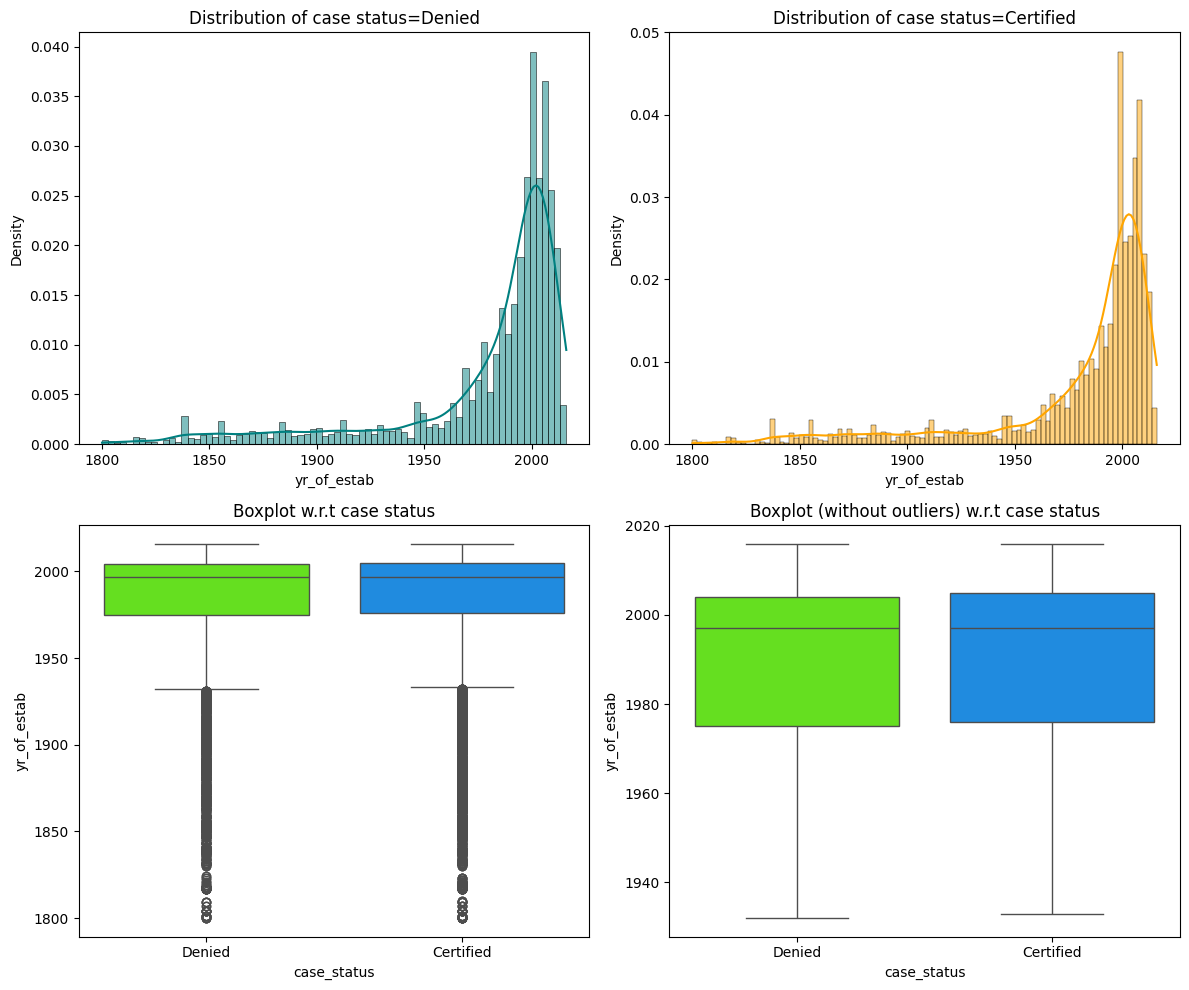

In [52]:
distribution_plot_wrt_target(easy_visa_df, "yr_of_estab", "case_status")

 - Denied and Certified cases both peak around the year 2000,we see growing trend in visa applications linked to newer companies, possibly driven by startup hiring or International expansion.
 - Both Denied and Certified applicants show similar median establishment years (around the year 2000).

#### Let's find out if unit of wage has any impact on visa applications getting certified.

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


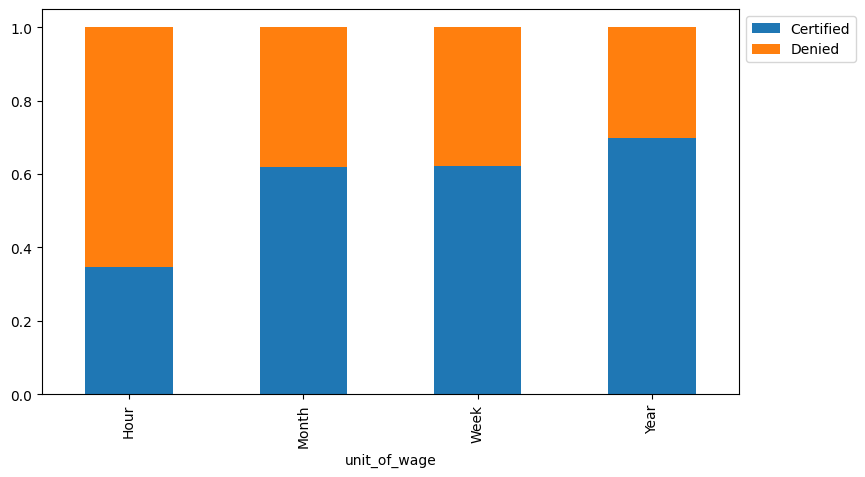

In [53]:
stacked_barplot(easy_visa_df, "unit_of_wage", "case_status")


 - Hourly waged applicants are more likely to get denied while yearly are more likley to get certified.

#### Observations on job experience and training required

requires_job_training      N     Y    All
has_job_experience                       
All                    22525  2955  25480
N                       8988  1690  10678
Y                      13537  1265  14802
------------------------------------------------------------------------------------------------------------------------


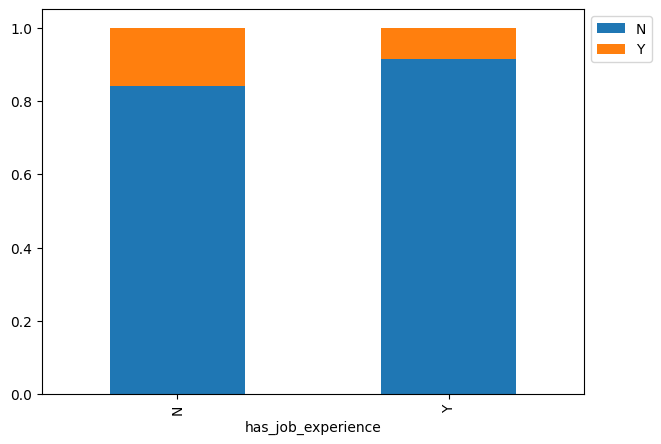

In [54]:
stacked_barplot(easy_visa_df, "has_job_experience", "requires_job_training")



 - Applicants with existing work experience tend to have lower training needs.

#### Observations on full_time_position and case_status

case_status         Certified  Denied    All
full_time_position                          
All                     17018    8462  25480
Y                       15163    7610  22773
N                        1855     852   2707
------------------------------------------------------------------------------------------------------------------------


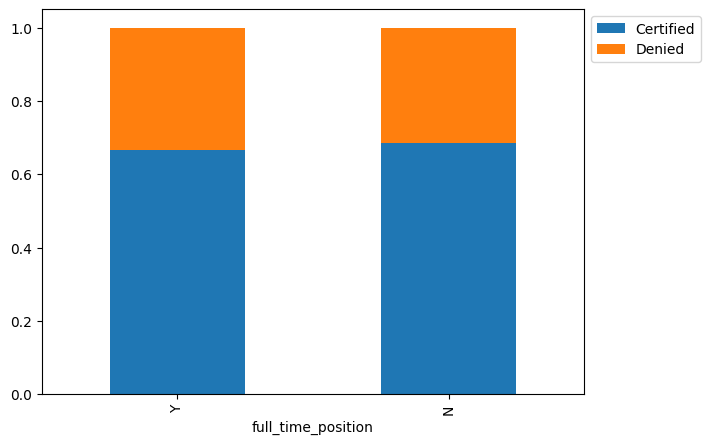

In [55]:
stacked_barplot(easy_visa_df, "full_time_position", "case_status")

 - Applicants in full time position are more likely to be certified.

# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

### Outlier Check

- Let's check for outliers in the data.

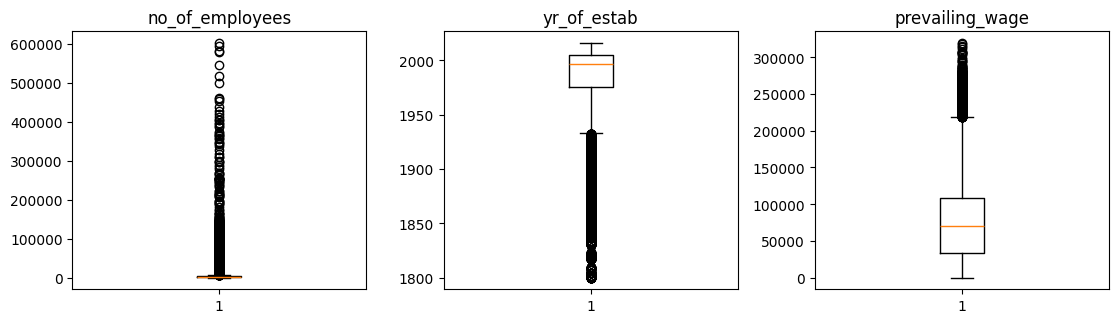

In [56]:
# outlier detection using boxplot
numeric_columns = easy_visa_df.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(easy_visa_df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

***Observations:***
 - Although there are outliers, we will keep them as they have a valuable input



### Data Preparation for modeling
   - First, we’ll convert all categorical columns into numeric form.
   - We want to predict which visa will be certified.
   - Before we proceed to build a model, we'll have to encode categorical features.
   - We'll split the data into train and test to be able to evaluate the model that we build on the train data.

In [57]:
# Splitting the dataset into features and target variable
X = easy_visa_df.drop(["case_status"], axis=1)
y = easy_visa_df["case_status"].apply(lambda x: 1 if x == "Certified" else 0)


In [58]:
# Split the data into training, validation and test set:

# first we split data into 2 parts, say temporary and test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)
# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)

In [59]:
#print the shape of train, validation or test sets
print("Shape of Training set : ", X_train.shape)
print("Shape of the Validation set: ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (15288, 10)
Shape of the Validation set:  (5096, 10)
Shape of test set :  (5096, 10)
Percentage of classes in training set:
case_status
1    0.667844
0    0.332156
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64


In [60]:
# Checking that no column has missing values in train, validation or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
dtype: int64
------------------------------
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
dtype: int64
------------------------------
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
dtype: int64


In [61]:
#Training Dataset
cols = X_train.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_train[i].value_counts())
    print("*" * 30)

continent
Asia             10085
Europe            2285
North America     1944
South America      528
Africa             333
Oceania            113
Name: count, dtype: int64
******************************
education_of_employee
Bachelor's     6141
Master's       5792
High School    2045
Doctorate      1310
Name: count, dtype: int64
******************************
has_job_experience
Y    8845
N    6443
Name: count, dtype: int64
******************************
requires_job_training
N    13477
Y     1811
Name: count, dtype: int64
******************************
region_of_employment
Northeast    4312
South        4248
West         3920
Midwest      2576
Island        232
Name: count, dtype: int64
******************************
unit_of_wage
Year     13786
Hour      1286
Week       156
Month       60
Name: count, dtype: int64
******************************
full_time_position
Y    13678
N     1610
Name: count, dtype: int64
******************************


In [62]:
#Validation Dataset
cols = X_val.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_val[i].value_counts())
    print("*" * 30)

continent
Asia             3395
Europe            713
North America     655
South America     173
Africa            121
Oceania            39
Name: count, dtype: int64
******************************
education_of_employee
Bachelor's     2033
Master's       1886
High School     694
Doctorate       483
Name: count, dtype: int64
******************************
has_job_experience
Y    2963
N    2133
Name: count, dtype: int64
******************************
requires_job_training
N    4501
Y     595
Name: count, dtype: int64
******************************
region_of_employment
Northeast    1430
South        1389
West         1352
Midwest       855
Island         70
Name: count, dtype: int64
******************************
unit_of_wage
Year     4576
Hour      452
Week       57
Month      11
Name: count, dtype: int64
******************************
full_time_position
Y    4552
N     544
Name: count, dtype: int64
******************************


In [63]:
#Test Dataset
cols = X_test.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_test[i].value_counts())
    print("*" * 30)

continent
Asia             3381
Europe            734
North America     693
South America     151
Africa             97
Oceania            40
Name: count, dtype: int64
******************************
education_of_employee
Bachelor's     2060
Master's       1956
High School     681
Doctorate       399
Name: count, dtype: int64
******************************
has_job_experience
Y    2994
N    2102
Name: count, dtype: int64
******************************
requires_job_training
N    4547
Y     549
Name: count, dtype: int64
******************************
region_of_employment
Northeast    1453
South        1380
West         1314
Midwest       876
Island         73
Name: count, dtype: int64
******************************
unit_of_wage
Year     4600
Hour      419
Week       59
Month      18
Name: count, dtype: int64
******************************
full_time_position
Y    4543
N     553
Name: count, dtype: int64
******************************


### Creating Dummy Variables

In [64]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 21) (5096, 21) (5096, 21)


# **EDA**



*   It is good idea to explore the data once again after manupulating.



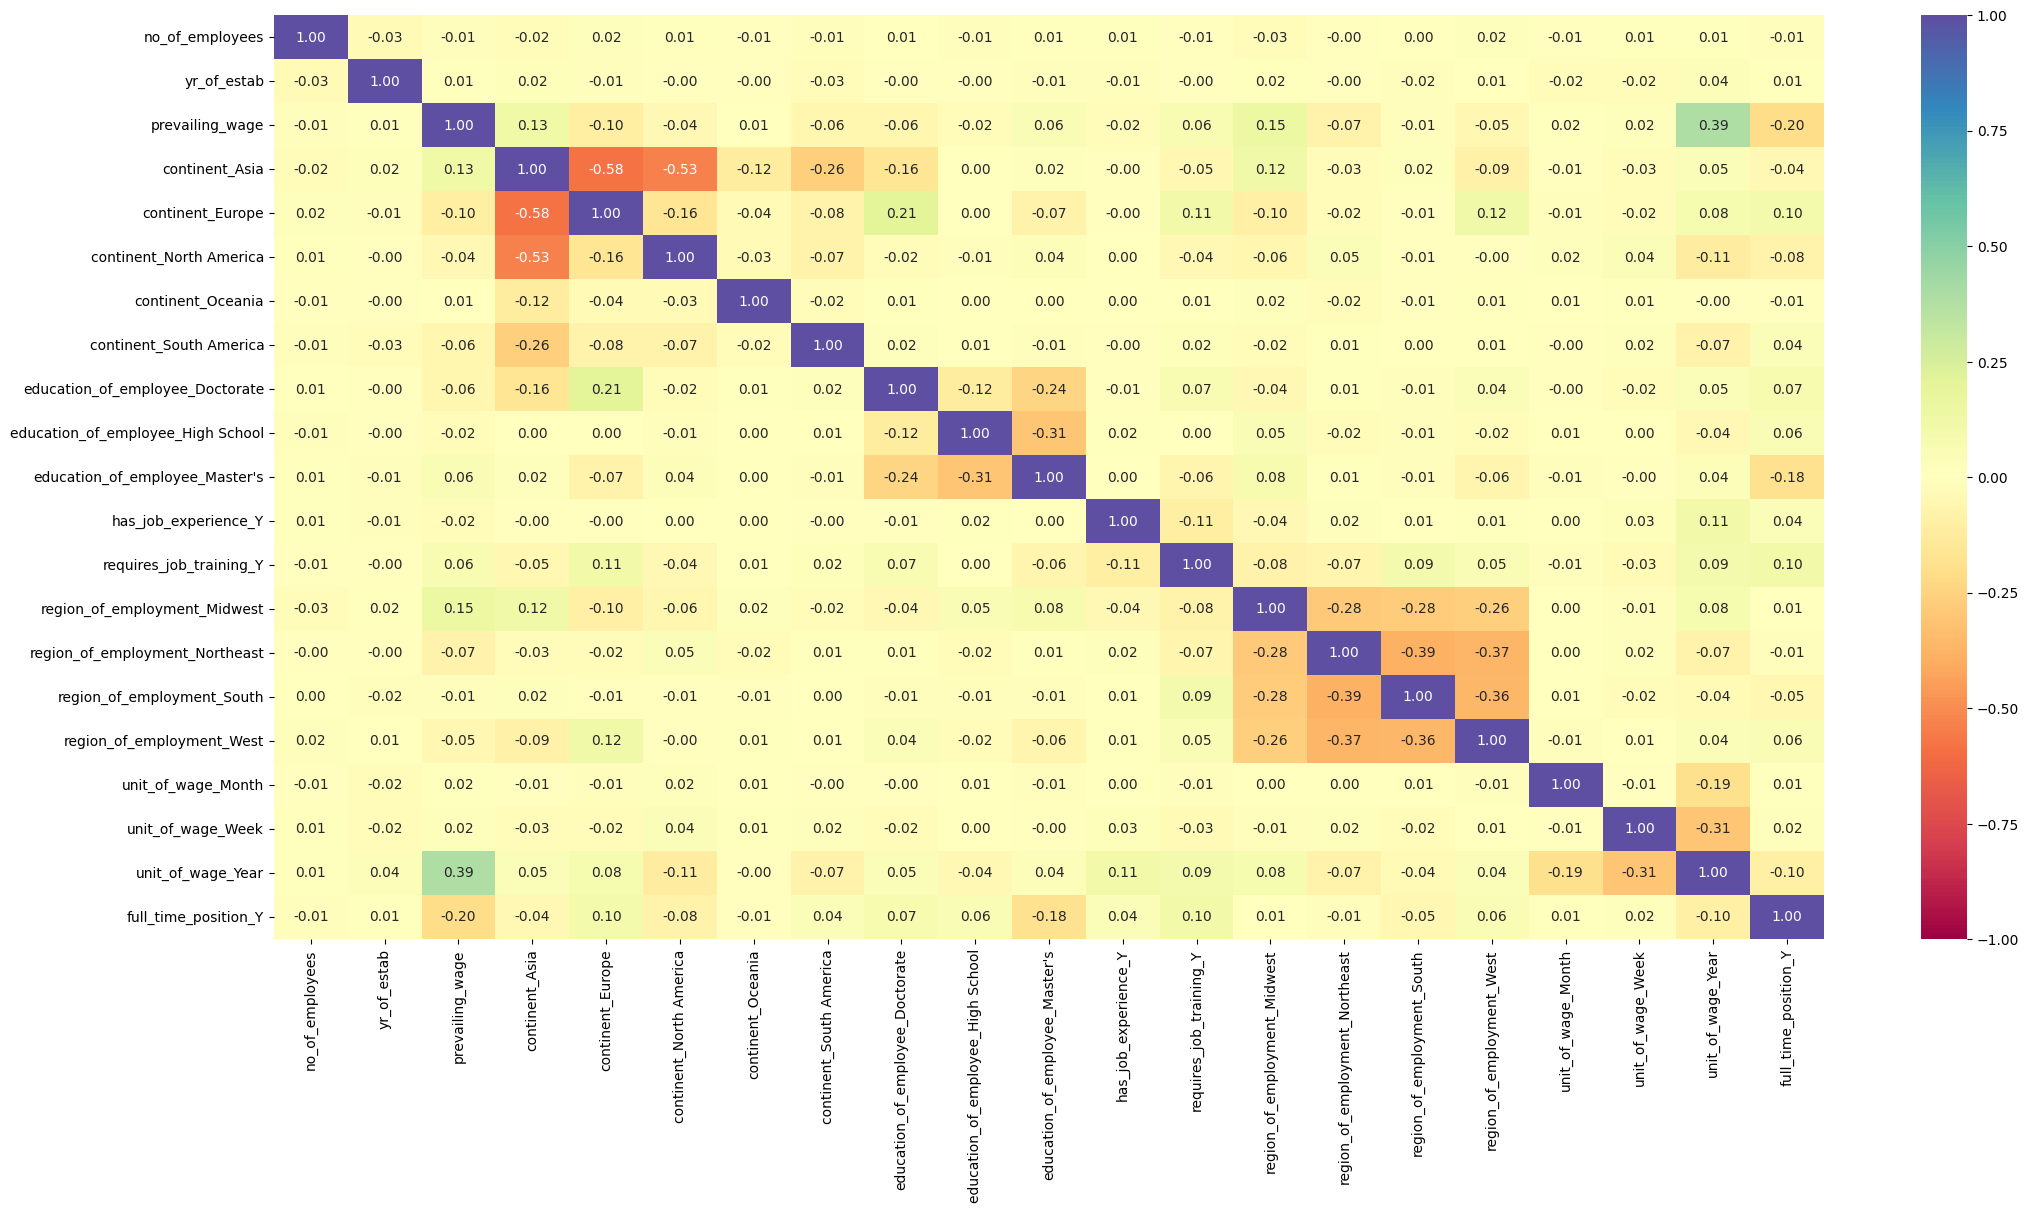

In [65]:
plt.figure(figsize=(25, 12))
sns.heatmap(X_train.corr(), annot=True, vmin=-1, vmax=1, fmt='.2f', cmap='Spectral')
plt.show()

In [66]:
#grouping the data by Region and case status
region_status = easy_visa_df.groupby(['region_of_employment', 'case_status']).size().unstack()
region_status['Approval Rate (%)'] = (region_status['Certified'] / region_status.sum(axis=1)) * 100
region_status = region_status.sort_values('Approval Rate (%)', ascending=False)
region_status


case_status,Certified,Denied,Approval Rate (%)
region_of_employment,,,
Midwest,3253,1054,75.528210
South,4913,2104,70.015676
Northeast,4526,2669,62.904795
West,4100,2486,62.253265
Island,226,149,60.266667


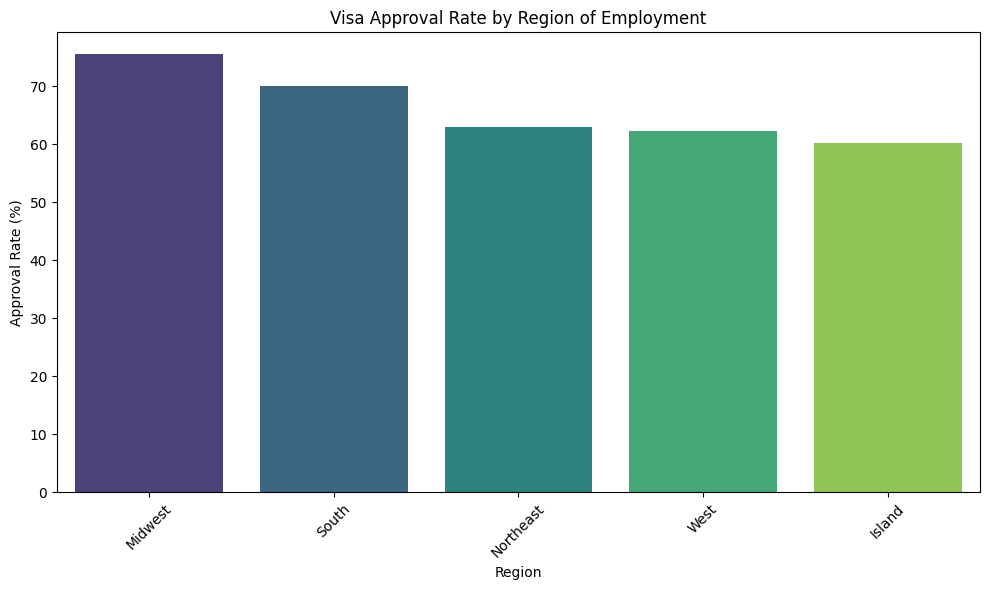

In [67]:
#Bar plot to visualize the Approval rate by Region
plt.figure(figsize=(10,6))
sns.barplot(x=region_status.index, y=region_status['Approval Rate (%)'], palette='viridis')
plt.title('Visa Approval Rate by Region of Employment')
plt.ylabel('Approval Rate (%)')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


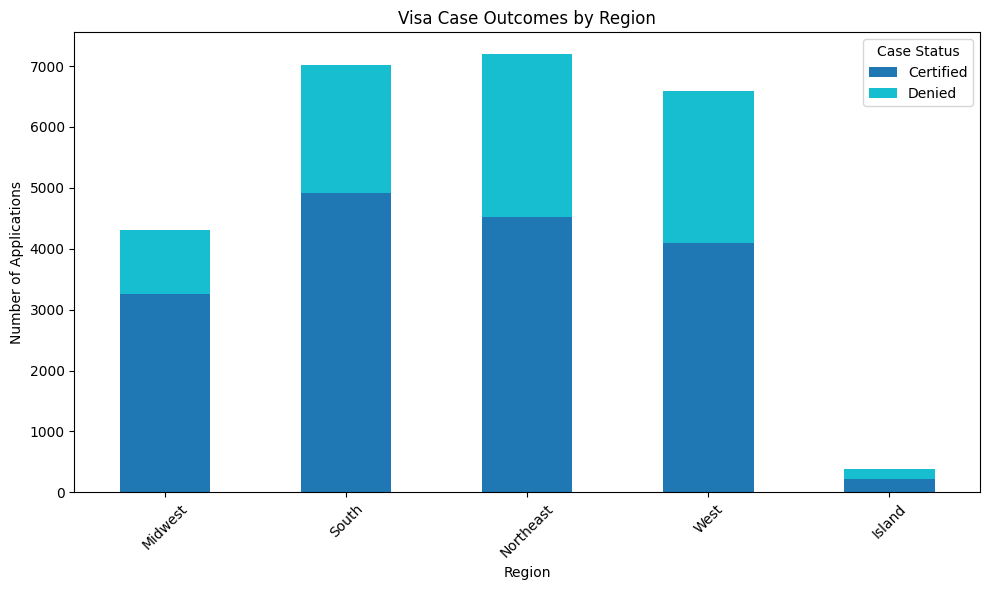

In [68]:
#stacked barplot to visualize certified vs Denied per region
region_status[['Certified', 'Denied']].plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab10')
plt.title('Visa Case Outcomes by Region')
plt.ylabel('Number of Applications')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.legend(title='Case Status')
plt.tight_layout()
plt.show()


 - We see the Midwest has highest approval rate (75.5%)
 - Northeast and West show elevated denials despite large volumes.
 - Island region shows lowest application count and approval rate.


# **Model Building**

## Model evaluation criterion

**Model can make wrong predictions as**:

1. Model predicts that the visa application will get certified but in reality, the visa application should get denied.
2. Model predicts that the visa application will not get certified but in reality, the visa application should get certified.

**Which case is more important?**
* Both the cases are important as:

* If a visa is certified when it had to be denied a wrong employee will get the job position while US citizens will miss the opportunity to work on that position.

* If a visa is denied when it had to be certified the U.S. will lose a suitable human resource that can contribute to the economy.


**How to reduce the losses?**

* `F1 Score` can be used a the metric for evaluation of the model, greater the F1  score higher are the chances of minimizing False Negatives and False Positives.
* We will use balanced class weights so that model focuses equally on both classes.

In [69]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {'Accuracy': acc, 'Recall': recall, 'Precision': precision, 'F1': f1,},
        index=[0],
    )

    return df_perf

In [70]:
# defining a function for confusion matrix
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ['{0:0.0f}'.format(item) + '\n{0:.2%}'.format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

## Model Building - Original Data

In [71]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(('Bagging', BaggingClassifier(random_state=1)))
models.append(('Random Forest', RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(('AdaBoost', AdaBoostClassifier(random_state=1)))
models.append(('Gradient Boosting', GradientBoostingClassifier(random_state=1)))
models.append(('XGBoost', XGBClassifier(random_state=1, eval_metric='logloss')))
models.append(('Decision Tree', DecisionTreeClassifier(random_state=1)))


print('\n' 'Training Performance:' '\n')
for name, model in models:
    model.fit(X_train, y_train)
    scores = f1_score(y_train, model.predict(X_train))
    print('{}: {}'.format(name, scores))

print('\n' 'Validation Performance:' '\n')

for name, model in models:
    model.fit(X_train, y_train)
    scores_val = f1_score(y_val, model.predict(X_val))
    print('{}: {}'.format(name, scores_val))


Training Performance:

Bagging: 0.989150179193873
Random Forest: 1.0
AdaBoost: 0.8204269947530306
Gradient Boosting: 0.8291218182658106
XGBoost: 0.8963229453814886
Decision Tree: 1.0

Validation Performance:

Bagging: 0.7736516357206012
Random Forest: 0.8049978941457251
AdaBoost: 0.8180081855388813
Gradient Boosting: 0.826637008202419
XGBoost: 0.8079119654547987
Decision Tree: 0.7434385137127691


***Observations:***

 - Bagging Classifier model shows Overfit.
 - RandomForest model shows Overfit.
 - AdaBoost model shows generalized performance.
 - GradientBoosting model also shows generalized performance.
 - DecisionTree classifier model shows Overfit.

## Model Building - Oversampled Data

In [72]:
print("Before Oversampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Certified': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'Denied': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Certified': 10210
Before Oversampling, counts of label 'Denied': 5078 

After Oversampling, counts of label 'Certified': 10210
After Oversampling, counts of label 'Denied': 10210 

After Oversampling, the shape of train_X: (20420, 21)
After Oversampling, the shape of train_y: (20420,) 



In [73]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(('Bagging', BaggingClassifier(random_state=1)))
models.append(('Random Forest', RandomForestClassifier(random_state=1, class_weight="balanced")))
models.append(('AdaBoost', AdaBoostClassifier(random_state=1)))
models.append(('Gradient Boosting', GradientBoostingClassifier(random_state=1)))
models.append(('XGBoost', XGBClassifier(random_state=1, eval_metric='logloss')))
models.append(('Decision Tree', DecisionTreeClassifier(random_state=1)))


print('\n' 'Training Performance:' '\n')
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print('\n' 'Validation Performance:' '\n')

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_val = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9875473741201949
Random Forest: 0.9999510260051913
AdaBoost: 0.8005498403689252
Gradient Boosting: 0.8072434234901815
XGBoost: 0.8708686342053813
Decision Tree: 1.0

Validation Performance:

Bagging: 0.7665171898355755
Random Forest: 0.7965442764578834
AdaBoost: 0.8195334879279771
Gradient Boosting: 0.8173049645390071
XGBoost: 0.8129304286718201
Decision Tree: 0.7320006012325266


***Observations:***

 - Bagging Classifier model shows Overfit.
 - RandomForest model shows Overfit.
 - AdaBoost model shows generalized performance.
 - GradientBoosting model also shows generalized performance.
 - DecisionTree classifier model shows Overfit.

## Model Building - Undersampled Data

In [74]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [75]:
print("Before Under Sampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Certified': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Certified': 10210
Before Under Sampling, counts of label 'Denied': 5078 

After Under Sampling, counts of label 'Certified': 5078
After Under Sampling, counts of label 'Denied': 5078 

After Under Sampling, the shape of train_X: (10156, 21)
After Under Sampling, the shape of train_y: (10156,) 



In [76]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(('Bagging', BaggingClassifier(random_state=1)))
models.append(('Random Forest', RandomForestClassifier(random_state=1, class_weight="balanced")))
models.append(('AdaBoost', AdaBoostClassifier(random_state=1)))
models.append(('Gradient Boosting', GradientBoostingClassifier(random_state=1)))
models.append(('XGBoost', XGBClassifier(random_state=1, eval_metric='logloss')))
models.append(('Decision Tree', DecisionTreeClassifier(random_state=1)))


print('\n' 'Training Performance:' '\n')
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = f1_score(y_train_un, model.predict(X_train_un))
    print('{}: {}'.format(name, scores))

print('\n' 'Validation Performance:' '\n')

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_val = f1_score(y_val, model.predict(X_val))
    print('{}: {}'.format(name, scores_val))


Training Performance:

Bagging: 0.9803687095166915
Random Forest: 1.0
AdaBoost: 0.7015343047380103
Gradient Boosting: 0.7281441717791411
XGBoost: 0.8720351390922401
Decision Tree: 1.0

Validation Performance:

Bagging: 0.7057046979865772
Random Forest: 0.7417218543046358
AdaBoost: 0.765990884802766
Gradient Boosting: 0.776595744680851
XGBoost: 0.7459304181295883
Decision Tree: 0.6955818093542644


***Observations:***

 - Bagging Classifier model shows Overfit.
 - RandomForest model shows Overfit.
 - AdaBoost model shows generalized performance.
 - GradientBoosting model also shows generalized performance.
 - DecisionTree classifier model shows Overfit.

# **Model Performance Improvement**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```


## Hyperparameter Tuning - Gradient Boosting Classifier

### Tuning GradientBoost Classifier model with Oversampled Data

In [77]:
%%time
# Choose the type of classifier.
gbc_tuned = GradientBoostingClassifier(
    init=AdaBoostClassifier(random_state=1), random_state=1
)

# Grid of parameters to choose from
parameters = {
    'n_estimators': np.arange(50,110,25),
    'subsample': [0.7,0.9],
    'max_features': [0.5,0.7,1],
    'learning_rate': [0.01,0.1,0.05],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=gbc_tuned, param_distributions=parameters, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = 1)

#Fitting parameters to training data
randomized_cv.fit(X_train_over,y_train_over)


print('Best parameters are {} with CV score={}:' .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': np.int64(100), 'max_features': 0.7, 'learning_rate': 0.1} with CV score=0.8004569314374181:
CPU times: user 8min 5s, sys: 1.04 s, total: 8min 7s
Wall time: 8min 12s


In [78]:
# Set the clf to the best combination of parameters
tuned_gb1 = randomized_cv.best_estimator_
# Fit the best algorithm to the data.
tuned_gb1.fit(X_train_over, y_train_over)


GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           max_features=0.7, n_estimators=np.int64(100),
                           random_state=1, subsample=0.7)

,Accuracy,Recall,Precision,F1
0,0.795201,0.853869,0.764201,0.80655


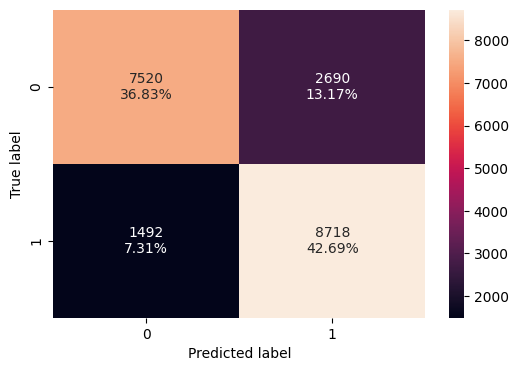

In [79]:
# Checking model performance on training set
confusion_matrix_sklearn(tuned_gb1, X_train_over, y_train_over)
gbc_tuned1_model_train_perf = model_performance_classification_sklearn(tuned_gb1, X_train_over, y_train_over)
gbc_tuned1_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.747253,0.85047,0.78797,0.818028


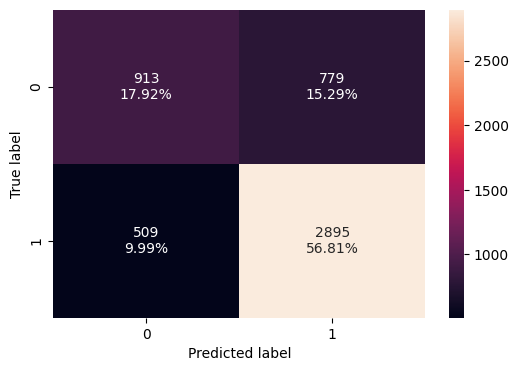

In [80]:
# Checking model performance on validation set
confusion_matrix_sklearn(tuned_gb1, X_val, y_val)
gbc_tuned1_model_val_perf = model_performance_classification_sklearn(tuned_gb1, X_val, y_val)
gbc_tuned1_model_val_perf

- Model shows generalized performance.

### Tuning GradientBoost Classifier model with Undersampled Data

In [81]:
%%time
# Choose the type of classifier.
gbc_tuned_un = GradientBoostingClassifier(
    init=AdaBoostClassifier(random_state=1), random_state=1
)

# Grid of parameters to choose from
parameters = {
    "n_estimators": np.arange(50,110,25),
    "subsample": [0.7,0.9],
    #"max_features": [0.7, 0.8, 0.9, 1],
    'max_features': [0.5,0.7,1],
    "learning_rate": [0.01,0.1,0.05],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=gbc_tuned_un, param_distributions=parameters, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = 1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)


print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': np.int64(75), 'max_features': 0.5, 'learning_rate': 0.05} with CV score=0.7155008791968351:
CPU times: user 4min 34s, sys: 753 ms, total: 4min 35s
Wall time: 4min 37s


In [82]:
# Set the clf to the best combination of parameters
tuned_gb2 = randomized_cv.best_estimator_
# Fit the best algorithm to the data.
tuned_gb2.fit(X_train_un, y_train_un)


GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_features=0.5,
                           n_estimators=np.int64(75), random_state=1,
                           subsample=0.7)

,Accuracy,Recall,Precision,F1
0,0.711008,0.751674,0.695137,0.722301


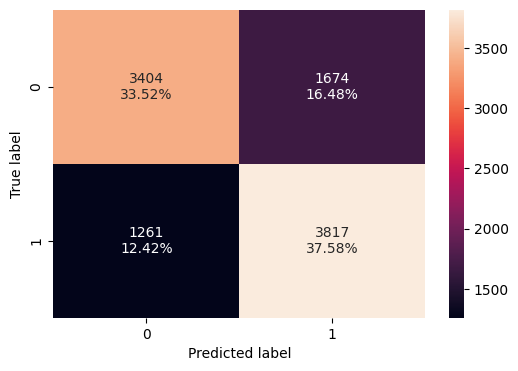

In [83]:
# Checking model performance on training set
confusion_matrix_sklearn(tuned_gb2, X_train_un, y_train_un)
gbc_tuned2_model_train_perf = model_performance_classification_sklearn(tuned_gb2, X_train_un, y_train_un)
gbc_tuned2_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.724882,0.745593,0.825634,0.783575


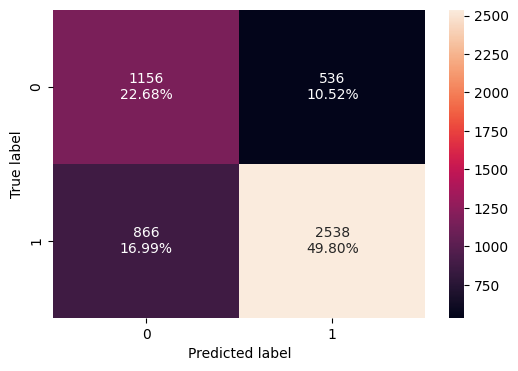

In [84]:
# Checking model performance on validation set
confusion_matrix_sklearn(tuned_gb2, X_val, y_val)
gbc_tuned2_model_val_perf = model_performance_classification_sklearn(tuned_gb2, X_val, y_val)
gbc_tuned2_model_val_perf

 - Model shows Underfit.

## Hyperparameter Tuning - AdaBoost Classifier

### Tuning AdaBoost Classifier model with Oversampled Data

In [85]:
%%time
# Choose the type of classifier.
abc_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    # Let's try different max_depth for estimator
    "estimator": [
        DecisionTreeClassifier(max_depth=1, class_weight="balanced", random_state=1),
        DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=1),
        DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=1),
    ],
    "n_estimators": np.arange(60, 100, 10),
    "learning_rate": np.arange(0.1, 0.4, 0.1),
}

# Type of scoring used to compare parameter  combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the randomizedSearch
randomized_cv = RandomizedSearchCV(estimator=abc_tuned, param_distributions=parameters, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = 1)
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

# Set the clf to the best combination of parameters
abc_tuned1 = randomized_cv.best_estimator_

# Fit the best algorithm to the data.
abc_tuned1.fit(X_train_over, y_train_over)

Best parameters are {'n_estimators': np.int64(90), 'learning_rate': np.float64(0.4), 'estimator': DecisionTreeClassifier(class_weight='balanced', max_depth=2, random_state=1)} with CV score=0.7942201132101875:
CPU times: user 8min 41s, sys: 922 ms, total: 8min 42s
Wall time: 8min 46s


AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                    max_depth=2,
                                                    random_state=1),
                   learning_rate=np.float64(0.4), n_estimators=np.int64(90),
                   random_state=1)

,Accuracy,Recall,Precision,F1
0,0.786141,0.833203,0.761525,0.795753


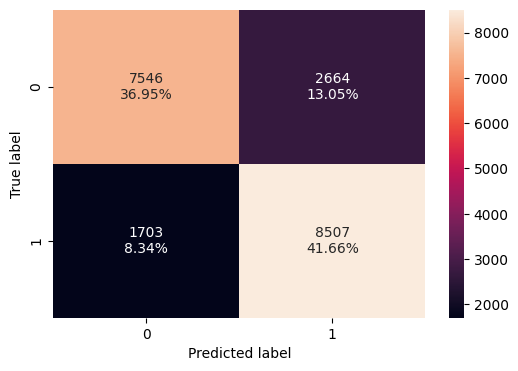

In [86]:
# Checking model performance on training set
confusion_matrix_sklearn(abc_tuned1, X_train_over, y_train_over)
abc_tuned1_model_train_perf = model_performance_classification_sklearn(abc_tuned1, X_train_over, y_train_over)
abc_tuned1_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.740581,0.827262,0.793239,0.809894


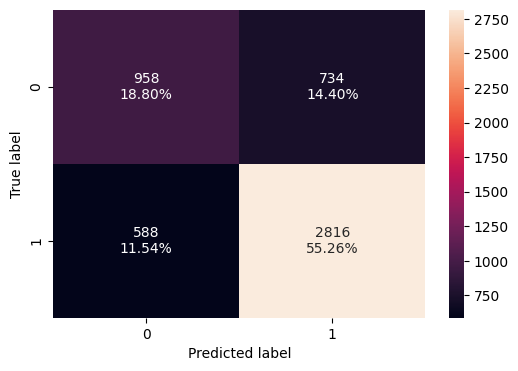

In [87]:
# Checking model performance on validation set
confusion_matrix_sklearn(abc_tuned1, X_val, y_val)
abc_tuned1_model_val_perf = model_performance_classification_sklearn(abc_tuned1, X_val, y_val)
abc_tuned1_model_val_perf

- After hypertuning, the model shows generalized performance.

## Hyperparameter Tuning - XGBoost Classifier

### Tuning XGBoost Classifier model with Oversampled Data

In [88]:
%%time
xgb_tuned = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=1)

# Grid of parameters to choose from
parameters = {
    "n_estimators": np.arange(150, 250, 50),
    "scale_pos_weight": [1, 2],
    "subsample": [0.9, 1],
    "learning_rate": np.arange(0.1, 0.21, 0.1),
    "gamma": [3, 5],
    "colsample_bytree": [0.8, 0.9],
    "colsample_bylevel": [ 0.9, 1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=xgb_tuned, param_distributions=parameters, n_iter=100, scoring=scorer,
                             cv=5,random_state=1, n_jobs = 1)

randomized_cv = randomized_cv.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
xgb_tuned1 = randomized_cv.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned1.fit(X_train_over, y_train_over)

CPU times: user 4min 52s, sys: 1.77 s, total: 4min 53s
Wall time: 2min 51s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=1, colsample_bynode=None, colsample_bytree=0.8,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=3, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=np.float64(0.1),
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(150), n_jobs=None,
              num_parallel_tree=None, ...)

In [89]:
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.9, 'scale_pos_weight': 2, 'n_estimators': np.int64(150), 'learning_rate': np.float64(0.1), 'gamma': 3, 'colsample_bytree': 0.8, 'colsample_bylevel': 1} with CV score=0.8131748482698434:


,Accuracy,Recall,Precision,F1
0,0.790157,0.955534,0.718039,0.819935


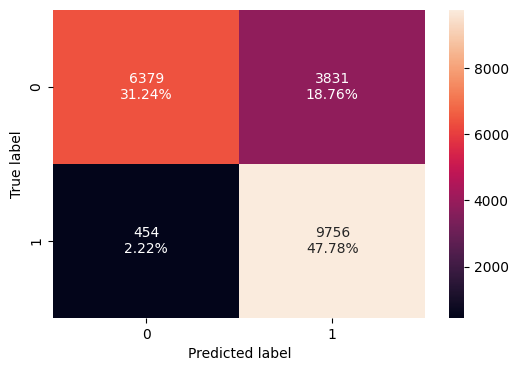

In [90]:
# Checking model's performance on training set
confusion_matrix_sklearn(xgb_tuned1, X_train_over, y_train_over)
xgb_tuned1_model_train_perf = model_performance_classification_sklearn(xgb_tuned1, X_train_over, y_train_over)
xgb_tuned1_model_train_perf


,Accuracy,Recall,Precision,F1
0,0.730965,0.939777,0.732875,0.823529


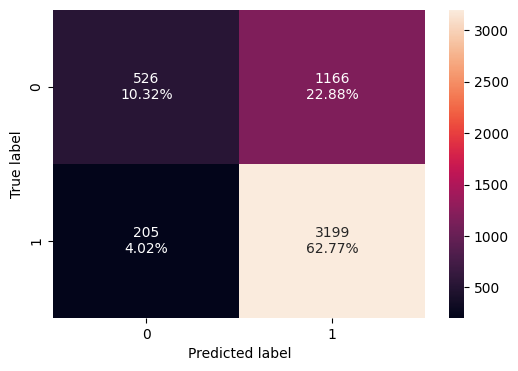

In [91]:
# Checking model's performance on validation set
confusion_matrix_sklearn(xgb_tuned1, X_val, y_val)
xgb_tuned1_model_val_perf = model_performance_classification_sklearn(xgb_tuned1, X_val, y_val)
xgb_tuned1_model_val_perf

 - After hypertuning the model shows generalized performance.

## Hyperparameter Tuning - Bagging Classifier

### Tuning Bagging Classifier model with Oversampled Data

In [92]:
%%time
# Choose the type of classifier.
bagging_tuned = BaggingClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    "max_samples": [0.7, 0.8, 0.9],
    "max_features": [0.7, 0.8, 0.9],
    "n_estimators": np.arange(90, 120, 10),
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the RandomSearchCV
randomized_cv = RandomizedSearchCV(estimator=bagging_tuned, param_distributions=parameters, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = 1)
randomized_cv.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
bagging_tuned = randomized_cv.best_estimator_

# Fit the best algorithm to the data.
bagging_tuned.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(110), 'max_samples': 0.9, 'max_features': 0.7} with CV score=0.8038405530964721:
CPU times: user 15min 8s, sys: 1.57 s, total: 15min 10s
Wall time: 15min 19s


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


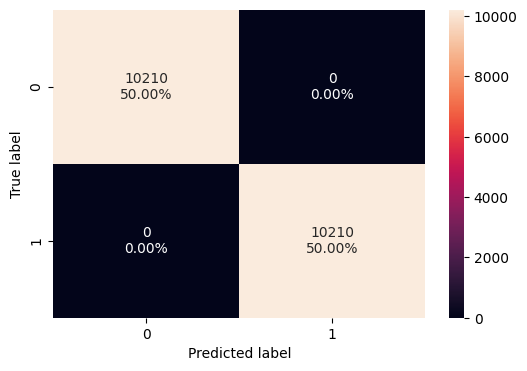

In [93]:
# Checking model's performance on training set
confusion_matrix_sklearn(bagging_tuned, X_train_over, y_train_over)
bagging_tuned_model_train_perf = model_performance_classification_sklearn(bagging_tuned, X_train_over, y_train_over)
bagging_tuned_model_train_perf


,Accuracy,Recall,Precision,F1
0,0.723901,0.834019,0.771258,0.801411


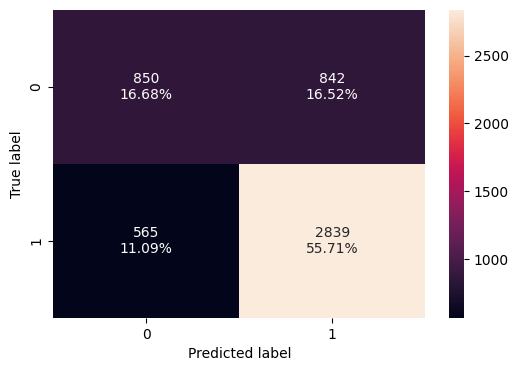

In [94]:
# Checking model's performance on validation set
confusion_matrix_sklearn(bagging_tuned, X_val, y_val)
bagging_tuned_model_val_perf = model_performance_classification_sklearn(bagging_tuned, X_val, y_val)
bagging_tuned_model_val_perf

- The bagging classifier shows overfitting even after tuning.

## Hyperparameter Tuning - RandomForest Classifier

### Tuning RandomForest Classifier model with Oversampled Data

In [95]:
%%time
rf_tuned = RandomForestClassifier(random_state=1, class_weight="balanced")

# Grid of parameters to choose from

param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=rf_tuned, param_distributions=parameters, n_iter=100, scoring=scorer,
                             cv=5,random_state=1, n_jobs = 1)

randomized_cv = randomized_cv.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
rf_tuned = randomized_cv.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(110), 'max_samples': 0.8, 'max_features': 0.7} with CV score=0.7942887719518537:
CPU times: user 14min 29s, sys: 2.18 s, total: 14min 31s
Wall time: 14min 38s


,Accuracy,Recall,Precision,F1
0,0.998923,0.999119,0.998727,0.998923


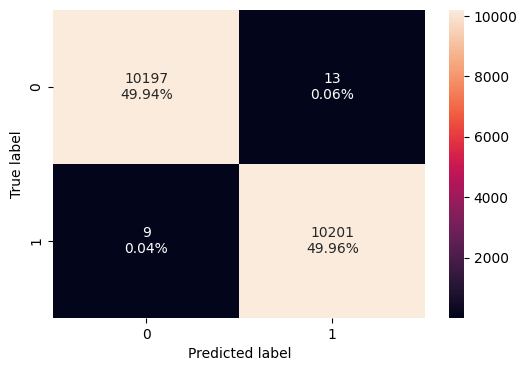

In [96]:
# Checking model's performance on training set
confusion_matrix_sklearn(rf_tuned, X_train_over, y_train_over)
rf_tuned_model_train_perf = model_performance_classification_sklearn(rf_tuned, X_train_over, y_train_over)
rf_tuned_model_train_perf


,Accuracy,Recall,Precision,F1
0,0.722135,0.822268,0.775346,0.798118


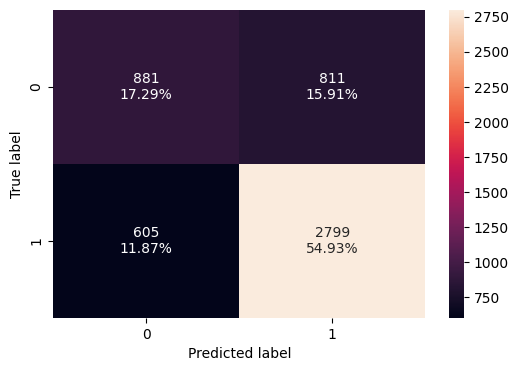

In [97]:
# Checking model's performance on validation set
confusion_matrix_sklearn(rf_tuned, X_val, y_val)
rf_tuned_model_val_perf = model_performance_classification_sklearn(rf_tuned, X_val, y_val)
rf_tuned_model_val_perf

- After hyperparameter tuning the model performance shows Overfit.

## Hyperparameter Tuning - DecisionTree Classifier

### Tuning DecisionTree Classifier model with Oversampled Data

In [98]:
%%time
dtc_tuned = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from

parameters = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=dtc_tuned, param_distributions=parameters, n_iter=100, scoring=scorer,
                             cv=5,random_state=1, n_jobs = 1)

randomized_cv = randomized_cv.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
dtc_tuned = randomized_cv.best_estimator_

# Fit the best algorithm to the data.
dtc_tuned.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'min_samples_leaf': 1, 'min_impurity_decrease': 0.0001, 'max_leaf_nodes': 15, 'max_depth': np.int64(5)} with CV score=0.758826184420497:
CPU times: user 12.1 s, sys: 22.7 ms, total: 12.1 s
Wall time: 12.2 s


,Accuracy,Recall,Precision,F1
0,0.742165,0.894711,0.685553,0.776291


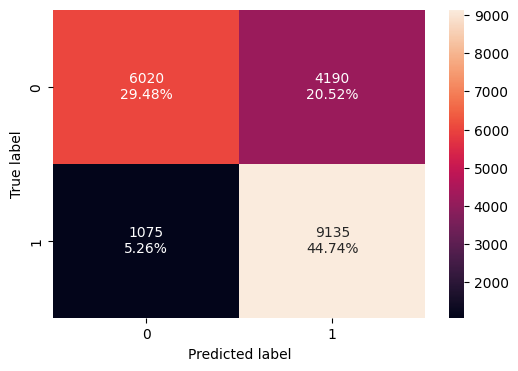

In [99]:
# Checking model's performance on training set
confusion_matrix_sklearn(dtc_tuned, X_train_over, y_train_over)
dtc_tuned_model_train_perf = model_performance_classification_sklearn(dtc_tuned, X_train_over, y_train_over)
dtc_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.734498,0.895417,0.753523,0.818365


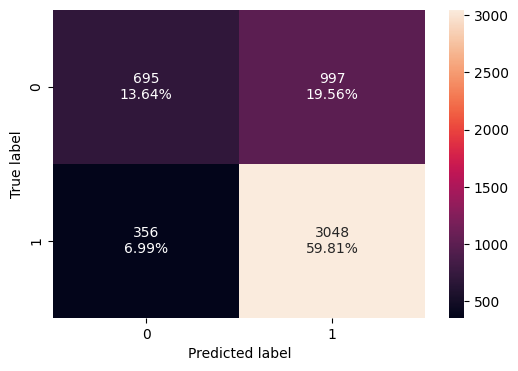

In [100]:
# Checking model's performance on validation set
confusion_matrix_sklearn(dtc_tuned, X_val, y_val)
dtc_tuned_model_val_perf = model_performance_classification_sklearn(dtc_tuned, X_val, y_val)
dtc_tuned_model_val_perf

 - Model shows generalized performance.

####Stacking Classifier Model

In [101]:
estimators = [
    ("AdaBoost", abc_tuned1),
    ("Gradient Boosting_over", tuned_gb1),
    ("Gradient Boosting_un", tuned_gb2),

]

final_estimator = xgb_tuned1

stacking_classifier = StackingClassifier(
    estimators=estimators, final_estimator=final_estimator
)

stacking_classifier.fit(X_train_over, y_train_over)

StackingClassifier(estimators=[('AdaBoost',
                                AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                    max_depth=2,
                                                                                    random_state=1),
                                                   learning_rate=np.float64(0.4),
                                                   n_estimators=np.int64(90),
                                                   random_state=1)),
                               ('Gradient Boosting_over',
                                GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                                                           max_features=0.7,
                                                           n_estimators=np.int64...
                                                 grow_policy=None,
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=np.float64(0.1),
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=None,
                                                 max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=np.int64(150),
                                                 n_jobs=None,
                                                 num_parallel_tree=None, ...))

In [102]:
#check model performance on oversampled training set
stacking_classifier_model_train_perf = model_performance_classification_sklearn(
    stacking_classifier, X_train_over, y_train_over
)
stacking_classifier_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.769197,0.949559,0.697833,0.804464


In [103]:
#check model performance on validation set
stacking_classifier_model_val_perf = model_performance_classification_sklearn(
    stacking_classifier, X_val, y_val
)
stacking_classifier_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.717425,0.938602,0.721871,0.816092


- Stacking model has also given a good and generalized performance.
- The performance is comparable to the XGBoost model.
- We have received F1 scores of 0.80 and around 0.82 on the training and validation set, respectively.

# **Model Comparison and Final Model Selection**

In [104]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
       gbc_tuned1_model_train_perf.T,
       gbc_tuned2_model_train_perf.T,
       abc_tuned1_model_train_perf.T,
       xgb_tuned1_model_train_perf.T,
       rf_tuned_model_train_perf.T,
       dtc_tuned_model_train_perf.T,
       bagging_tuned_model_train_perf.T,
       stacking_classifier_model_train_perf.T,

    ],
    axis=1,
)
models_train_comp_df.columns = [
     'Gradient boosting trained with Oversampled data',
     'Gradient boosting trained with Undersampled data',
     'AdaBoost trained with Oversampled data',
     'XGBoost trained with Oversampled data',
     'RandomForest trained with Oversampled data',
     'DecisionTree trained with Oversampled data',
     'Bagging trained with Oversampled data',
     'stacking trained with Oversampled data'

]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient boosting trained with Oversampled data,Gradient boosting trained with Undersampled data,AdaBoost trained with Oversampled data,XGBoost trained with Oversampled data,RandomForest trained with Oversampled data,DecisionTree trained with Oversampled data,Bagging trained with Oversampled data,stacking trained with Oversampled data
Accuracy,0.795201,0.711008,0.786141,0.790157,0.998923,0.742165,1.0,0.769197
Recall,0.853869,0.751674,0.833203,0.955534,0.999119,0.894711,1.0,0.949559
Precision,0.764201,0.695137,0.761525,0.718039,0.998727,0.685553,1.0,0.697833
F1,0.806550,0.722301,0.795753,0.819935,0.998923,0.776291,1.0,0.804464


In [105]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
       gbc_tuned1_model_val_perf.T,
       gbc_tuned2_model_val_perf.T,
       abc_tuned1_model_val_perf.T,
       xgb_tuned1_model_val_perf.T,
       rf_tuned_model_val_perf.T,
       dtc_tuned_model_val_perf.T,
       bagging_tuned_model_val_perf.T,
       stacking_classifier_model_val_perf.T,

    ],
     axis=1,
)
models_val_comp_df.columns = [
    'Gradient boosting validated with Oversampled data',
    'Gradient boosting validated with Undersampled data',
    'AdaBoost validated with Oversampled data',
    'XGBoost validated with Oversampled data',
    'RandomForest validated with Oversampled data',
    'DecisionTree validated with Oversampled data',
    'Bagging validated with Oversampled data',
    'stacking validated with Oversampled data'

]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Gradient boosting validated with Oversampled data,Gradient boosting validated with Undersampled data,AdaBoost validated with Oversampled data,XGBoost validated with Oversampled data,RandomForest validated with Oversampled data,DecisionTree validated with Oversampled data,Bagging validated with Oversampled data,stacking validated with Oversampled data
Accuracy,0.747253,0.724882,0.740581,0.730965,0.722135,0.734498,0.723901,0.717425
Recall,0.850470,0.745593,0.827262,0.939777,0.822268,0.895417,0.834019,0.938602
Precision,0.787970,0.825634,0.793239,0.732875,0.775346,0.753523,0.771258,0.721871
F1,0.818028,0.783575,0.809894,0.823529,0.798118,0.818365,0.801411,0.816092


- The XGBoost model on Oversampled data shows a good and generalized performance
- We see the F1 score of 0.819(around 0.82) and 0.82 on the training and Validation set respectively.
- We use tuned XGBoost model as the final model.

In [106]:
# check the performance on test set with best model
final_xgb_test = model_performance_classification_sklearn(xgb_tuned1, X_test, y_test)
final_xgb_test



,Accuracy,Recall,Precision,F1
0,0.719192,0.93537,0.72446,0.816515


 - We see the F1 score of 0.816(around 0.82) in the test set.

###Important features of Final Model

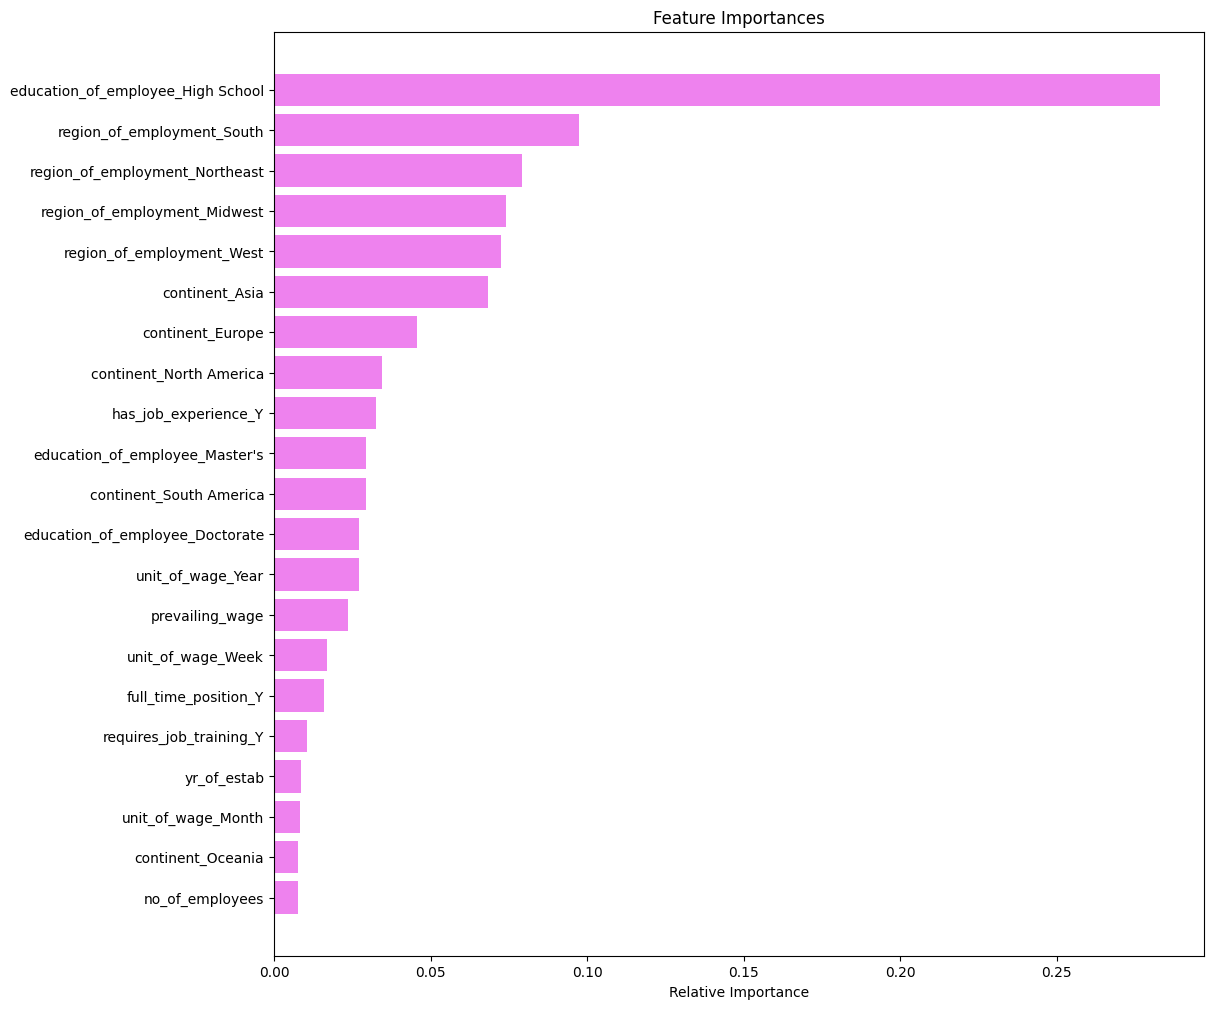

In [107]:
feature_names = X_train.columns
importances = xgb_tuned1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

 - The top three important features to look for while certifying a visa are :      
      - Education Level of Employee (High School)
      - Region of Employment (South, Northeast, Midwest, West) and
      - Continent of Origin (Asia, Europe, North America).

# **Actionable Insights and Recommendations**

###Insights




 Applicant Profile with High Likelihood of Visa Approval:
       
  -  Education level : High school education ranks unexpectedly high in importance, potentially reflecting targeted workforce needs in specific regions like the South and Northeast.
  -  Applicants with Bachelor's, Master's, or Doctorate higher education level still show increased approval probabilities.
  -  Region of Employment: The South and Northeast regions exhibit the highest importance for visa approval. The Midwest and West also contribute meaningfully, indicating widespread demand across multiple regions.
  -  Continent : Applicants from Asia, Europe, North America demonstrate strong positive impact on visa certification outcomes.
  -  Job Experience: Applicants with prior work experience demonstrate consistently higher chances of visa approval.
  -  Unit of wage : Applicatants having yearly unit of wage see higher approval rates.
  - Prevailing wage : Approved cases trend towards the median prevailing wage around $72k.

Applicant Profile with Likelihood of Visa Denied:

  - Education level : Doesn't have any degree and has completed high school.
  - Job Experience : Doesn't have any prior job experience.
  - Prevailing wage : The median prevailing wage of the employees for whom the visa got certified is around 65k.
  -  Continent - Ideally the nationality and ethnicity of an applicant shouldn't matter to work in a country but it has been observed that applicants from South America, Africa  and Oceania have higher chances of visa applications getting denied.
  - Unit of Wage - Applicants having an hourly unit of wage.











###Recommendations

   - Additional data can be collected from both employers and employees to enrich model performance and also to provide better insights:
      - From employers: Salary breakdowns, operational domain, staffing trends.
      - From employees: Subject-matter expertise, Number of years of experience, professional qualifications

___